In [1]:
import torch
import torch.nn as nn
from torch.autograd import Function
torch.set_default_dtype(torch.float64)
import pickle
import numpy as np
from scipy.linalg import svd
from scipy.sparse import csc_matrix
import matplotlib.pyplot as plt
import hashlib
from copy import deepcopy
import scipy.io as spio
import time
import scipy
from pypower.api import case118
from pypower.api import opf, makeYbus, makeB
from pypower import idx_bus, idx_gen, ppoption
from scipy.sparse import csr_matrix
import copy
def str_to_bool(value):
    if isinstance(value, bool):
        return value
    if value.lower() in {'false', 'f', '0', 'no', 'n'}:
        return False
    elif value.lower() in {'true', 't', '1', 'yes', 'y'}:
        return True
    raise ValueError('{value} is not a valid boolean value')

def my_hash(string):
    return hashlib.sha1(bytes(string, 'utf-8')).hexdigest()

import torch.optim as optim
torch.set_default_dtype(torch.float64)

import operator
from functools import reduce
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import pickle
import time
import os
import argparse

print(torch.cuda.device_count())
DEVICE = torch.device("cuda:1") if torch.cuda.is_available() else torch.device("cpu")
print(DEVICE)
DEVICE = "cpu"

0
cpu


In [2]:
parser = argparse.ArgumentParser(description='DC3')
parser.add_argument('--probType', type=str, default='acopf57', help='problem type')
parser.add_argument('--epochs', type=int, default=100,
    help='number of neural network epochs')
parser.add_argument('--batchSize', type=int, default=32,
    help='training batch size')
parser.add_argument('--lr', type=float, default=0.0005,
    help='neural network learning rate')
parser.add_argument('--hiddenSize', type=int, default=50,
    help='hidden layer size for neural network')
parser.add_argument('--saveAllStats', type=str_to_bool, default=False,
    help='whether to save all stats, or just those from latest epoch')
parser.add_argument('--resultsSaveFreq', type=int, default=10,
    help='how frequently (in terms of number of epochs) to save stats to file')

args = parser.parse_args([])
args = vars(args) # change to dictionary

# for key in defaults.keys():
#     if args[key] is None:
#         args[key] = defaults[key]
print(args)

{'probType': 'acopf57', 'epochs': 100, 'batchSize': 32, 'lr': 0.0005, 'hiddenSize': 50, 'saveAllStats': False, 'resultsSaveFreq': 10}


In [3]:
CASE_FNS = dict([(118, case118)])
ppc = CASE_FNS[118]()

ppc['branch'][:,8] = 0 # no tap ratio
ppc['branch'][:,9] = 0 # no angle shifter

ppc['branch'][:,11] = 0 
ppc['branch'][:,12] = 0 
# ppc['branch'][:,5:6] = bfmax

# ppc["connect_matrix"] = connect_matrix

In [4]:
class ACOPFProblem:
    """
        minimize_{p_g, q_g, vmag, vang} p_g^T A p_g + b p_g + c
        s.t.                  p_g min   <= p_g  <= p_g max
                              q_g min   <= q_g  <= q_g max
                              vmag min  <= vmag <= vmag max
                              vang_slack = \theta_slack   # voltage angle     
                              (p_g - p_d) + (q_g - q_d)i = diag(vmag e^{i*vang}) conj(Y) (vmag e^{-i*vang})
    """

    def __init__(self, filename, ppc, branch_flow, num, valid_frac=0.1, test_frac=0.2):

        self.nbus = int(filename.split('_')[-1][4:-4])

        ## Define useful power network quantities and indices
        data = spio.loadmat(filename)
        
        self.ppc = ppc

        self.genbase = ppc['gen'][:, idx_gen.MBASE]
        self.baseMVA = ppc['baseMVA'] * 1.0
        # self.connect_matrix = ppc['connect_matrix'][:,0]
        # self.branch_nonbinding = branch_nonbinding
        
        self.slack = np.where(ppc['bus'][:, idx_bus.BUS_TYPE] == 3)[0]
        self.pv = np.where(ppc['bus'][:, idx_bus.BUS_TYPE] == 2)[0]
        self.spv = np.concatenate([self.slack, self.pv])
        self.spv.sort()
        self.pq = np.setdiff1d(range(self.nbus), self.spv)
        self.nonslack_idxes = np.sort(np.concatenate([self.pq, self.pv]))
        self.allbus_idxes = np.arange(self.nbus)

        # indices within gens
        self.slack_ = np.array([np.where(x == self.spv)[0][0] for x in self.slack])
        self.pv_ = np.array([np.where(x == self.spv)[0][0] for x in self.pv])
        self.pv_nonslack_idxes = np.array([np.where(x == self.nonslack_idxes)[0][0] for x in self.pv])
        
        self.ng = ppc['gen'].shape[0]
        self.allgen_idxes = np.arange(self.ng)
        self.nslack = len(self.slack)
        self.npv = len(self.pv)
        self.nbr = ppc['branch'].shape[0]
        # self.nbr_reduced = self.branch_nonbinding.shape[0]
        
        self.quad_costs = torch.tensor(ppc['gencost'][:,4], dtype=torch.get_default_dtype())
        self.lin_costs  = torch.tensor(ppc['gencost'][:,5], dtype=torch.get_default_dtype())
        self.const_cost = ppc['gencost'][:,6].sum()

        self.pmax = torch.tensor(ppc['gen'][:,idx_gen.PMAX] / self.genbase, dtype=torch.get_default_dtype())
        self.pmin = torch.tensor(ppc['gen'][:,idx_gen.PMIN] / self.genbase, dtype=torch.get_default_dtype())
        self.qmax = torch.tensor(ppc['gen'][:,idx_gen.QMAX] / self.genbase, dtype=torch.get_default_dtype())
        self.qmin = torch.tensor(ppc['gen'][:,idx_gen.QMIN] / self.genbase, dtype=torch.get_default_dtype())
        self.vmax = torch.tensor(ppc['bus'][:,idx_bus.VMAX], dtype=torch.get_default_dtype())
        self.vmin = torch.tensor(ppc['bus'][:,idx_bus.VMIN], dtype=torch.get_default_dtype())
        self.slackva = torch.tensor([np.deg2rad(ppc['bus'][self.slack, idx_bus.VA])], dtype=torch.get_default_dtype()).squeeze(-1)
        self.bfmax = torch.tensor((ppc['branch'][:,5] / self.baseMVA)**2, dtype=torch.get_default_dtype())
        
        ppc2 = deepcopy(ppc)
        ppc2['bus'][:,0] -= 1
        ppc2['branch'][:,[0,1]] -= 1
        Ybus, Yf, _ = makeYbus(self.baseMVA, ppc2['bus'], ppc2['branch'])
        Ybus = Ybus.todense()
        Yfbus = Yf.todense()
        self.Ybusr = torch.tensor(np.real(Ybus), dtype=torch.get_default_dtype())
        self.Ybusi = torch.tensor(np.imag(Ybus), dtype=torch.get_default_dtype())
        self.Yfbusr = torch.tensor(np.real(Yfbus), dtype=torch.get_default_dtype())
        self.Yfbusi = torch.tensor(np.imag(Yfbus), dtype=torch.get_default_dtype())
        self.line_susceptance = ppc2['branch'][:,4]
        
        Bp, Bpp = makeB(self.baseMVA, ppc2['bus'], ppc2['branch'], 2)
        Bp = Bp.todense()
        Bpp = Bpp.todense()
        Bp_reduced = Bp[np.concatenate([self.pv, self.pq]),:][:,np.concatenate([self.pv, self.pq])]
        Bpp_reduced = Bpp[np.concatenate([self.pq]),:][:,np.concatenate([self.pq])]
        self.Bp = torch.inverse(torch.tensor(Bp_reduced, dtype=torch.get_default_dtype()))
        self.Bpp = torch.inverse(torch.tensor(Bpp_reduced, dtype=torch.get_default_dtype()))
        
        Bp_reduced1 = Bp[self.nonslack_idxes, :][:, self.nonslack_idxes]
        Bpp_reduced1 = Bpp[self.nonslack_idxes, :][:, self.nonslack_idxes]
        self.Bp1 = torch.inverse(torch.tensor(Bp_reduced1, dtype=torch.get_default_dtype()))
        self.Bpp1 = torch.inverse(torch.tensor(Bpp_reduced1, dtype=torch.get_default_dtype()))
        
        self.F_BUS = ppc2['branch'][:,0].astype(int)
        self.T_BUS = ppc2['branch'][:,1].astype(int)
        # self.F_BUS_reduced = ppc2['branch'][:, 0][self.branch_nonbinding].astype(int)
        # self.T_BUS_reduced = ppc2['branch'][:, 1][self.branch_nonbinding].astype(int)
        
        ppc3 = deepcopy(ppc2)
        ppc3['branch'][:,4] = 0 
        _, Yf_nosus, _ = makeYbus(self.baseMVA, ppc3['bus'], ppc3['branch'])
        Yfbus_nosus = Yf_nosus.todense()
        self.Yfbusr_nosus = torch.tensor(np.real(Yfbus_nosus), dtype=torch.get_default_dtype())
        self.Yfbusi_nosus = torch.tensor(np.imag(Yfbus_nosus), dtype=torch.get_default_dtype())
        
        self.Cf = torch.tensor(np.transpose(csr_matrix((np.ones(self.nbr), (range(self.nbr), self.F_BUS)), (self.nbr, self.nbus)).todense()), dtype=torch.get_default_dtype())
        self.Ct = torch.tensor(np.transpose(csr_matrix((np.ones(self.nbr), (range(self.nbr), self.T_BUS)), (self.nbr, self.nbus)).todense()), dtype=torch.get_default_dtype())
        self.adj = self.Cf - self.Ct
        ## Define optimization problem input and output variables
        demand = data['Dem'].T / self.baseMVA
        gen =  data['Gen'].T / self.genbase
        voltage = data['Vol'].T
        branch_flow = branch_flow / self.baseMVA / self.baseMVA
        
        X = np.concatenate([np.real(demand), np.imag(demand)], axis=1)[:num,:]
        Y = np.concatenate([np.real(gen), np.imag(gen), np.abs(voltage), np.angle(voltage), branch_flow], axis=1)[:num,:]
        feas_mask =  ~np.isnan(Y).any(axis=1)

        self._X = torch.tensor(X[feas_mask], dtype=torch.get_default_dtype())
        self._Y = torch.tensor(Y[feas_mask], dtype=torch.get_default_dtype())
        self._xdim = X.shape[1]
        self._ydim = Y.shape[1]
        self._num = feas_mask.sum()

        self._neq = 2*self.nbus
        self._nineq = 4*self.ng + 2*self.nbus
        self._nknowns = self.nslack

        # indices of useful quantities in full solution
        self.pg_start_yidx = 0
        self.qg_start_yidx = self.ng
        self.vm_start_yidx = 2*self.ng
        self.va_start_yidx = 2*self.ng + self.nbus
        self.bf_start_yidx = 2*self.ng + 2*self.nbus 
        ## Define train/valid/test split
        self._valid_frac = valid_frac
        self._test_frac = test_frac

        ## Define variables and indices for "partial completion" neural network

        # pg (non-slack) and |v|_g (including slack)
        self._partial_vars = np.concatenate([self.pg_start_yidx + self.pv_, self.vm_start_yidx + self.spv, self.va_start_yidx + self.slack])
        self._partial_vars_bf = np.concatenate([self.spv, self.nbus + self.slack])
        self._other_vars = np.setdiff1d(np.arange(self.ydim), self._partial_vars)
        self._partial_unknown_vars = np.concatenate([self.pg_start_yidx + self.pv_, self.vm_start_yidx + self.spv])

        # initial values for solver
        self.vm_init = ppc['bus'][:, idx_bus.VM]
        self.va_init = np.deg2rad(ppc['bus'][:, idx_bus.VA])
        self.pg_init = ppc['gen'][:, idx_gen.PG] / self.genbase
        self.qg_init = ppc['gen'][:, idx_gen.QG] / self.genbase

        # voltage angle at slack buses (known)
        self.slack_va = self.va_init[self.slack]

        # indices of useful quantities in partial solution
        self.pg_pv_zidx = np.arange(self.npv)
        self.vm_spv_zidx = np.arange(self.npv, 2*self.npv + self.nslack)
        
        # indices of useful quantities in partial solution for post processing
        self.pg_zidx = np.arange(self.npv)
        self.qg_zidx = np.arange(self.npv, self.npv+self.npv)
        
        # useful indices for equality constraints
        self.pflow_start_eqidx = 0
        self.qflow_start_eqidx = self.nbus


        ### For Pytorch
        self._device = None

    @property
    def X(self):
        return self._X

    @property
    def Y(self):
        return self._Y

    @property
    def partial_vars(self):
        return self._partial_vars
    
    @property
    def partial_vars_bf(self):
        return self._partial_vars_bf
    
    @property
    def other_vars(self):
        return self._other_vars

    @property
    def partial_unknown_vars(self):
        return self._partial_unknown_vars

    @property
    def xdim(self):
        return self._xdim

    @property
    def ydim(self):
        return self._ydim

    @property
    def num(self):
        return self._num

    @property
    def neq(self):
        return self._neq

    @property
    def nineq(self):
        return self._nineq

    @property
    def nknowns(self):
        return self._nknowns

    @property
    def valid_frac(self):
        return self._valid_frac

    @property
    def test_frac(self):
        return self._test_frac

    @property
    def train_frac(self):
        return 1 - self.valid_frac - self.test_frac

    @property
    def trainX(self):
        return self.X[:int(self.num * self.train_frac)]

    @property
    def validX(self):
        return self.X[int(self.num * self.train_frac):int(self.num * (self.train_frac + self.valid_frac))]

    @property
    def testX(self):
        return self.X[int(self.num * (self.train_frac + self.valid_frac)):]

    @property
    def trainY(self):
        return self.Y[:int(self.num*self.train_frac)]

    @property
    def validY(self):
        return self.Y[int(self.num*self.train_frac):int(self.num*(self.train_frac + self.valid_frac))]

    @property
    def testY(self):
        return self.Y[int(self.num*(self.train_frac + self.valid_frac)):]
    
    @property
    def device(self):
        return self._device
    
    def trainX_fake(self, X, num_fake):
        return X[:int(num_fake*self.train_frac)]

    def validX_fake(self, X, num_fake):
        return X[int(num_fake*self.train_frac):int(num_fake*(self.train_frac + self.valid_frac))]

    def testX_fake(self, X, num_fake):
        return X[int(num_fake*(self.train_frac + self.valid_frac)):]
    
    def trainY_fake(self, Y, num_fake):
        return Y[:int(num_fake*self.train_frac)]

    def validY_fake(self, Y, num_fake):
        return Y[int(num_fake*self.train_frac):int(num_fake*(self.train_frac + self.valid_frac))]

    def testY_fake(self, Y, num_fake):
        return Y[int(num_fake*(self.train_frac + self.valid_frac)):]
    
    
    def get_yvars(self, Y):
        pg = Y[:, :self.ng]
        qg = Y[:, self.ng:2*self.ng]
        vm = Y[:, 2*self.ng:2*self.ng+self.nbus]
        va = Y[:, 2*self.ng+self.nbus:2*self.ng+2*self.nbus]
        return pg, qg, vm, va

    def obj_fn(self, Y):
        pg, _, _, _, = self.get_yvars(Y)
        pg_mw = pg * torch.tensor(self.genbase).to(self.device)
        cost = (self.lin_costs * pg_mw).sum(axis=1) 
        return cost / (self.genbase.mean() ** 2)
    
    def eq_resid(self, X, Y):
        pg, qg, vm, va = self.get_yvars(Y)

        vr = vm*torch.cos(va)
        vi = vm*torch.sin(va)

        ## power balance equations
        tmp1 = vr@self.Ybusr - vi@self.Ybusi
        tmp2 = -vr@self.Ybusi - vi@self.Ybusr

        # real power
        pg_expand = torch.zeros(pg.shape[0], self.nbus, device=self.device)
        pg_expand[:, self.spv] = pg
        real_resid = (pg_expand - X[:, :self.nbus]) - (vr*tmp1 - vi*tmp2)

        # reactive power
        qg_expand = torch.zeros(qg.shape[0], self.nbus, device=self.device)
        qg_expand[:, self.spv] = qg
        react_resid = (qg_expand - X[:, self.nbus:]) - (vr*tmp2 + vi*tmp1)

        ## all residuals
        resids = torch.cat([
            real_resid,
            react_resid
        ], dim=1)
        
        return resids

    def eq_resid_bf(self, X, Y):
        _, _, vm, va, _ = self.get_yvars(Y)

        vr = vm*torch.cos(va)
        vi = vm*torch.sin(va)

        vfr = vr@self.Cf # 8 *41
        vfi = vi@self.Cf # 8 *41

        ## power balance equations
        tmp1 = vr@torch.transpose(self.Yfbusr,0,1) - vi@torch.transpose(self.Yfbusi,0,1) # batch_size * nbr
        tmp2 = -vr@torch.transpose(self.Yfbusi,0,1) - vi@torch.transpose(self.Yfbusr,0,1)

        # real power flow
        pf = (vfr*tmp1 - vfi*tmp2)

        # reactive power flow
        qf = (vfr*tmp2 + vfi*tmp1)

        return pf, qf
    
    def eq_resid_bf_reduced(self, X, Y):
        _, _, vm, va, _ = self.get_yvars(Y)

        vr = vm*torch.cos(va)
        vi = vm*torch.sin(va)

        vfr = vr@self.Cf[:, self.branch_nonbinding] # 8 *41
        vfi = vi@self.Cf[:, self.branch_nonbinding] # 8 *41

        ## power balance equations
        tmp1 = vr@torch.transpose(self.Yfbusr[self.branch_nonbinding, :],0,1) - vi@torch.transpose(self.Yfbusi[self.branch_nonbinding, :],0,1) # batch_size * nbr
        tmp2 = -vr@torch.transpose(self.Yfbusi[self.branch_nonbinding, :],0,1) - vi@torch.transpose(self.Yfbusr[self.branch_nonbinding, :],0,1)

        # real power flow
        pf = (vfr*tmp1 - vfi*tmp2)

        # reactive power flow
        qf = (vfr*tmp2 + vfi*tmp1)

        return pf, qf
    
    def ineq_resid(self, X, Y):
        pg, qg, vm, va = self.get_yvars(Y)
        resids = torch.cat([
            pg - self.pmax,
            self.pmin - pg,
            qg - self.qmax,
            self.qmin - qg,
            vm - self.vmax,
            self.vmin - vm
        ], dim=1)
        return resids

    def ineq_dist(self, X, Y):
        resids = self.ineq_resid(X, Y)
        return torch.clamp(resids, 0)
    
    def eq_grad(self, X, Y):
        eq_jac = self.eq_jac(Y)
        eq_resid = self.eq_resid(X,Y)
        return 2*eq_jac.transpose(1,2).bmm(eq_resid.unsqueeze(-1)).squeeze(-1)

    def ineq_grad(self, X, Y):
        ineq_jac = self.ineq_jac(Y)
        ineq_dist = self.ineq_dist(X, Y)
        return 2*ineq_jac.transpose(1,2).bmm(ineq_dist.unsqueeze(-1)).squeeze(-1)
    
    def eq_jac_pfqf(self, Y):
        
        _, _, vm, va, _ = self.get_yvars(Y)

        dreal_dvm = torch.zeros(vm.shape[0], self.nbr*2, device=self.device)
        dreal_dva = torch.zeros(vm.shape[0], self.nbr, device=self.device)
        dreact_dvm = torch.zeros(vm.shape[0], self.nbr*2, device=self.device)
        dreact_dva = torch.zeros(vm.shape[0], self.nbr, device=self.device)
        Yfr = self.Yfbusr_nosus
        Yfi = self.Yfbusi_nosus
        i = 0
        for k in range (0, self.nbr*2, 2):
            from_bus = self.F_BUS[i]
            to_bus = self.T_BUS[i]
            # real power equations
            dreal_dvm[:, k] = -2*Yfr[i, from_bus]*vm[:, from_bus] \
            +vm[:, to_bus]*(Yfr[i, from_bus]*torch.cos(va[:, from_bus] - va[:, to_bus]) + Yfi[i, from_bus]*torch.sin(va[:, from_bus] - va[:, to_bus]))
            dreal_dvm[:, k+1] = vm[:, from_bus]*(Yfr[i, from_bus]*torch.cos(va[:, from_bus] - va[:, to_bus]) + Yfi[i, from_bus]*torch.sin(va[:, from_bus] - va[:, to_bus]))

            dreal_dva[:, i] = vm[:, from_bus] * vm[:, to_bus]*(-Yfr[i, from_bus]*torch.sin(va[:, from_bus] - va[:, to_bus]) + Yfi[i, from_bus]*torch.cos(va[:, from_bus] - va[:, to_bus]))
            # dreal_dva[:, k+1] = vm[:, from_bus] * vm[:, to_bus]*(Yfr[i, from_bus]*torch.sin(va[:, from_bus] - va[:, to_bus]) - Yfi[i, from_bus]*torch.cos(va[:, from_bus] - va[:, to_bus]))
#             dreal_dva[:, k+1] = - dreal_dva[:, k]

            # reactive power equations
            dreact_dvm[:, k] = (self.line_susceptance[i] + 2*Yfi[i, from_bus]) *vm[:, from_bus] \
            +vm[:, to_bus]*(Yfr[i, from_bus]*torch.sin(va[:, from_bus] - va[:, to_bus]) - Yfi[i, from_bus]*torch.cos(va[:, from_bus] - va[:, to_bus]))
            dreact_dvm[:, k+1] = vm[:, from_bus]*(Yfr[i, from_bus]*torch.sin(va[:, from_bus] - va[:, to_bus]) - Yfi[i, from_bus]*torch.cos(va[:, from_bus] - va[:, to_bus]))

            dreact_dva[:, i] = vm[:, from_bus] * vm[:, to_bus]*(Yfr[i, from_bus]*torch.cos(va[:, from_bus] - va[:, to_bus]) + Yfi[i, from_bus]*torch.sin(va[:, from_bus] - va[:, to_bus]))
            # dreact_dva[:, k+1] = -vm[:, from_bus] * vm[:, to_bus]*(Yfr[i, from_bus]*torch.cos(va[:, from_bus] - va[:, to_bus]) + Yfi[i, from_bus]*torch.sin(va[:, from_bus] - va[:, to_bus]))
#             dreact_dva[:, k+1] = - dreact_dva[:, k]

            i = i + 1
        
        return torch.cat([dreal_dvm, dreact_dvm, dreal_dva, dreact_dva], dim=1)
    
    def eq_jac_bf_modi2(self, Y, Pf, Qf, eq_jac):

        from_index = np.arange(0, self.nbr*2, 2) 
        to_index = np.arange(1, self.nbr*2, 2) 

        dreal_dvm = eq_jac[:, :self.nbr*2]
        dreact_dvm = eq_jac[:, self.nbr*2:self.nbr*4]
        dreal_dva = eq_jac[:, self.nbr*4:self.nbr*5]
        dreact_dva = eq_jac[:, -self.nbr:]

        Sf_vmf = 2 * Pf * -dreal_dvm[:, from_index] + 2 * Qf * -dreact_dvm[:, from_index]
        Sf_vmt = 2 * Pf * -dreal_dvm[:, to_index] + 2 * Qf * -dreact_dvm[:, to_index]
        Sf_vaf = 2 * Pf * -dreal_dva + 2 * Qf * -dreact_dva

        return torch.cat([Sf_vmf, Sf_vmt, Sf_vaf], dim=1)    
    
    def eq_jac_equ(self, Y):
        _, _, vm, va, _ = self.get_yvars(Y)
        Yr = self.Ybusr
        Yi = self.Ybusi
        dreal_dvm = torch.zeros(vm.shape[0], self.nbus, self.nbus, device=self.device)
        dreal_dva = torch.zeros(vm.shape[0], self.nbus, self.nbus, device=self.device)
        dreact_dvm = torch.zeros(vm.shape[0], self.nbus, self.nbus, device=self.device)
        dreact_dva = torch.zeros(vm.shape[0], self.nbus, self.nbus, device=self.device)

        for i in range (self.nbus):
            connect_bus = (self.connect_matrix[i] - 1).astype(int) 
            dreal_dvm[:, i, i] = -2 * Yr[i, i] * vm[:, i]
            dreact_dvm[:, i, i] = 2 * Yi[i, i] * vm[:, i]
            for j in connect_bus:
                
                k = j.item()
                tmp1 = Yr[i, k] * torch.cos(va[:, i] - va[:, k]) + Yi[i, k] * torch.sin(va[:, i] - va[:, k])
                tmp2 = Yr[i, k] * torch.sin(va[:, i] - va[:, k]) - Yi[i, k] * torch.cos(va[:, i] - va[:, k])
                tmp_V = vm[:, i] * vm[:, k]
                
                dreal_dvm[:, i, i] = dreal_dvm[:, i, i] - vm[:, k] * tmp1

                dreal_dvm[:, i, k] = -vm[:, i] * tmp1

                dreal_dva[:, i, k] = - tmp_V * tmp2

                # dreal_dva[:, i, i] = dreal_dva[:, i, i] + vm[:, i] * vm[:, k] * tmp2
                dreal_dva[:, i, i] = dreal_dva[:, i, i] - dreal_dva[:, i, k]

                dreact_dvm[:, i, i] = dreact_dvm[:, i, i] - vm[:, k] * tmp2

                dreact_dvm[:, i, k] = - vm[:, i] * tmp2

                dreact_dva[:, i, k] = tmp_V * tmp1

                dreact_dva[:, i, i] = dreact_dva[:, i, i] - dreact_dva[:, i, k]

                # dreact_dva[:, i, i] = dreact_dva[:, i, i] - vm[:, i] * vm[:, k] * tmp1

        jac = torch.cat([
            torch.cat([dreal_dvm, dreal_dva], dim=2),
            torch.cat([dreact_dvm, dreact_dva], dim=2)],
            dim=1)

        return jac
     
    def eq_jac(self, Y):
        _, _, vm, va = self.get_yvars(Y)

        # helper functions
        mdiag = lambda v1, v2: torch.diag_embed(v1).bmm(torch.diag_embed(v2))
        Ydiagv = lambda Y, v: Y.unsqueeze(0).expand(v.shape[0], *Y.shape).bmm(torch.diag_embed(v))
        dtm = lambda v, M: torch.diag_embed(v).bmm(M)

        # helper quantities
        cosva = torch.cos(va)
        sinva = torch.sin(va)
        vr = vm * torch.cos(va)
        vi = vm * torch.sin(va)
        Yr = self.Ybusr
        Yi = self.Ybusi
        YrvrYivi = vr@Yr - vi@Yi
        YivrYrvi = vr@Yi + vi@Yr

        # real power equations
        dreal_dpg = torch.zeros(self.nbus, self.ng, device=self.device) 
        dreal_dpg[self.spv, :] = torch.eye(self.ng, device=self.device)
        dreal_dvm = -mdiag(cosva, YrvrYivi) - dtm(vr, Ydiagv(Yr, cosva)-Ydiagv(Yi, sinva)) \
            -mdiag(sinva, YivrYrvi) - dtm(vi, Ydiagv(Yi, cosva)+Ydiagv(Yr, sinva))
        dreal_dva = -mdiag(-vi, YrvrYivi) - dtm(vr, Ydiagv(Yr, -vi)-Ydiagv(Yi, vr)) \
            -mdiag(vr, YivrYrvi) - dtm(vi, Ydiagv(Yi, -vi)+Ydiagv(Yr, vr))
        
        # reactive power equations
        dreact_dqg = torch.zeros(self.nbus, self.ng, device=self.device)
        dreact_dqg[self.spv, :] = torch.eye(self.ng, device=self.device)
        dreact_dvm = mdiag(cosva, YivrYrvi) + dtm(vr, Ydiagv(Yi, cosva)+Ydiagv(Yr, sinva)) \
            -mdiag(sinva, YrvrYivi) - dtm(vi, Ydiagv(Yr, cosva)-Ydiagv(Yi, sinva))
        dreact_dva = mdiag(-vi, YivrYrvi) + dtm(vr, Ydiagv(Yi, -vi)+Ydiagv(Yr, vr)) \
            -mdiag(vr, YrvrYivi) - dtm(vi, Ydiagv(Yr, -vi)-Ydiagv(Yi, vr))

        jac = torch.cat([
            torch.cat([dreal_dpg.unsqueeze(0).expand(vr.shape[0], *dreal_dpg.shape), 
                torch.zeros(vr.shape[0], self.nbus, self.ng, device=self.device), 
                dreal_dvm, dreal_dva], dim=2),
            torch.cat([torch.zeros(vr.shape[0], self.nbus, self.ng, device=self.device), 
                dreact_dqg.unsqueeze(0).expand(vr.shape[0], *dreact_dqg.shape),
                dreact_dvm, dreact_dva], dim=2)],
            dim=1)

        return jac
    
    # Solves for the full set of variables
    def complete_partial(self, X, Z):
        Y_partial = torch.zeros(Z.shape, device=self.device)

        # Re-scale real powers
        Y_partial[:, self.pg_pv_zidx] = Z[:, self.pg_pv_zidx] * self.pmax[self.pv_] + \
             (1-Z[:, self.pg_pv_zidx]) * self.pmin[self.pv_]
        
        # Re-scale real parts of voltages
        Y_partial[:, self.vm_spv_zidx] = Z[:, self.vm_spv_zidx] * self.vmax[self.spv] + \
            (1-Z[:, self.vm_spv_zidx]) * self.vmin[self.spv]

        return Y_partial 
    
    def complete_partial_clamp(self, X, Z):
        Y_partial = torch.zeros(Z.shape, device=self.device)

        # Re-scale real powers
        Y_partial[:, self.pg_pv_zidx] = torch.clamp(Z[:, self.pg_pv_zidx], self.pmin[self.pv_], self.pmax[self.pv_])
        
                # Re-scale real parts of voltages
        Y_partial[:, self.vm_spv_zidx] = Z[:, self.vm_spv_zidx] * self.vmax[self.spv] + \
            (1-Z[:, self.vm_spv_zidx]) * self.vmin[self.spv]
       
        return Y_partial 
        # Solves for the full set of variables
    def complete_partial_tanh(self, X, Z):
        Y_partial = torch.zeros(Z.shape, device=self.device)

        # Re-scale real powers
        Y_partial[:, self.pg_pv_zidx] = (self.pmax[self.pv_] - self.pmin[self.pv_]) * 0.5 * Z[:, self.pg_pv_zidx] + \
        (self.pmax[self.pv_] + self.pmin[self.pv_]) * 0.5
        
        # Re-scale real parts of voltages
        Y_partial[:, self.vm_spv_zidx] = (self.vmax[self.spv] - self.vmin[self.spv]) * 0.5 * Z[:, self.vm_spv_zidx] + \
        (self.vmax[self.spv] + self.vmin[self.spv]) * 0.5

        return Y_partial 


In [5]:
def PFFunction(data, tol=1e-5, bsz=200, max_iters=50):
    class PFFunctionFn(Function):
        @staticmethod
        def forward(ctx, X, Z):

            ## Step 1: Newton's method
            Y = torch.zeros(X.shape[0], data.ydim - data.nbr, device=DEVICE)
            
            # known/estimated values (pg at pv buses, vm at all gens, va at slack bus)
            Y[:, data.pg_start_yidx + data.pv_] = Z[:, data.pg_pv_zidx]    # pg at non-slack gens
            Y[:, data.vm_start_yidx + data.spv] = Z[:, data.vm_spv_zidx]   # vm at gens
            Y[:, data.va_start_yidx + data.slack] = torch.tensor(data.slack_va, device=DEVICE)  # va at slack bus

            # init guesses for remaining values
            Y[:, data.vm_start_yidx + data.pq] = torch.tensor(data.vm_init[data.pq], device=DEVICE)  # vm at load buses
            Y[:, data.va_start_yidx + data.pv] = torch.tensor(data.va_init[data.pv], device=DEVICE)  # va at non-slack gens 
            Y[:, data.va_start_yidx + data.pq] = torch.tensor(data.va_init[data.pq], device=DEVICE)  # va at load buses
            Y[:, data.qg_start_yidx:data.qg_start_yidx+data.ng] = 0    # qg at gens (not used in Newton upd)
            Y[:, data.pg_start_yidx+data.slack_] = 0                   # pg at slack (not used in Newton upd)

            keep_constr = np.concatenate([
                data.pflow_start_eqidx + data.pv,     # real power flow at non-slack gens
                data.pflow_start_eqidx + data.pq,     # real power flow at load buses
                data.qflow_start_eqidx + data.pq])    # reactive power flow at load buses
            newton_guess_inds = np.concatenate([             
                data.vm_start_yidx + data.pq,         # vm at load buses
                data.va_start_yidx + data.pv,         # va at non-slack gens
                data.va_start_yidx + data.pq])        # va at load buses

            converged = torch.zeros(X.shape[0])
            jacs = []
            newton_jacs_inv = []
            for b in range(0, X.shape[0], bsz):
                # print('batch: {}'.format(b))
                X_b = X[b:b+bsz]
                Y_b = Y[b:b+bsz]

                for i in range(max_iters):
                    # print(i)
                    gy = data.eq_resid(X_b, Y_b)[:, keep_constr]
                    jac_full = data.eq_jac(Y_b)
                    jac = jac_full[:, keep_constr, :]
                    newton_jac_inv = torch.inverse(jac[:, :, newton_guess_inds])
                    delta = newton_jac_inv.bmm(gy.unsqueeze(-1)).squeeze(-1)
                    Y_b[:, newton_guess_inds] -= delta
                    if torch.norm(delta, dim=1).abs().max() < tol:
                        break

                converged[b:b+bsz] = (delta.abs() < tol).all(dim=1)
                jacs.append(jac_full)
                newton_jacs_inv.append(newton_jac_inv)


            ## Step 2: Solve for remaining variables

            # solve for qg values at all gens (note: requires qg in Y to equal 0 at start of computation)
            Y[:, data.qg_start_yidx:data.qg_start_yidx + data.ng] = \
                -data.eq_resid(X, Y)[:, data.qflow_start_eqidx + data.spv]
            # solve for pg at slack bus (note: requires slack pg in Y to equal 0 at start of computation)
            Y[:, data.pg_start_yidx + data.slack_] = \
                -data.eq_resid(X, Y)[:, data.pflow_start_eqidx + data.slack]

            ctx.data = data
            ctx.save_for_backward(torch.cat(jacs), torch.cat(newton_jacs_inv),
                torch.tensor(newton_guess_inds, device=DEVICE), 
                torch.tensor(keep_constr, device=DEVICE))

            return Y

        @staticmethod
        def backward(ctx, dl_dy):

            data = ctx.data
            jac, newton_jac_inv, newton_guess_inds, keep_constr = ctx.saved_tensors

            ## Step 2 (calc pg at slack and qg at gens)

            # gradient of all voltages through step 3 outputs
            last_eqs = np.concatenate([data.pflow_start_eqidx + data.slack, data.qflow_start_eqidx + data.spv])
            last_vars = np.concatenate([
                data.pg_start_yidx + data.slack_, np.arange(data.qg_start_yidx, data.qg_start_yidx + data.ng)])
            jac3 = jac[:, last_eqs, :]
            dl_dvmva_3 = -jac3[:, :, data.vm_start_yidx:].transpose(1,2).bmm(
                dl_dy[:, last_vars].unsqueeze(-1)).squeeze(-1)

            # gradient of pd at slack and qd at gens through step 3 outputs
            dl_dpdqd_3 = dl_dy[:, last_vars]

            # insert into correct places in x and y loss vectors
            dl_dy_3 = torch.zeros(dl_dy.shape, device=DEVICE)
            dl_dy_3[:, data.vm_start_yidx:] = dl_dvmva_3

            dl_dx_3 = torch.zeros(dl_dy.shape[0], data.xdim, device=DEVICE)
            dl_dx_3[:, np.concatenate([data.slack, data.nbus + data.spv])] = dl_dpdqd_3


            ## Step 1
            dl_dy_total = dl_dy_3 + dl_dy  # Backward pass vector including result of last step

            # Use precomputed inverse jacobian
            jac2 = jac[:, keep_constr, :]
            d_int = newton_jac_inv.transpose(1,2).bmm(
                            dl_dy_total[:,newton_guess_inds].unsqueeze(-1)).squeeze(-1)

            dl_dz_2 = torch.zeros(dl_dy.shape[0], data.npv + data.ng, device=DEVICE)
            dl_dz_2[:, data.pg_pv_zidx] = -d_int[:, :data.npv]  # dl_dpg at pv buses
            dl_dz_2[:, data.vm_spv_zidx] = -jac2[:, :, data.vm_start_yidx + data.spv].transpose(1,2).bmm(
                d_int.unsqueeze(-1)).squeeze(-1)

            dl_dx_2 = torch.zeros(dl_dy.shape[0], data.xdim, device=DEVICE)
            dl_dx_2[:, data.pv] = d_int[:, :data.npv]                       # dl_dpd at pv buses
            dl_dx_2[:, data.pq] = d_int[:, data.npv:data.npv+len(data.pq)]  # dl_dpd at pq buses
            dl_dx_2[:, data.nbus + data.pq] = d_int[:, -len(data.pq):]      # dl_dqd at pq buses


            # Final quantities
            dl_dx_total = dl_dx_3 + dl_dx_2
            dl_dz_total = dl_dz_2 + dl_dy_total[:, np.concatenate([
                data.pg_start_yidx + data.pv_, data.vm_start_yidx + data.spv])]

            return dl_dx_total, dl_dz_total


    return PFFunctionFn.apply

In [6]:
def PFFunction_eval(data, tol=1e-5, bsz=32, bsz2=32, max_iters=30):
    class PFFunctionFn_eval(Function):
        @staticmethod
        def forward(ctx, X, Z):

            ## Step 1: Newton's method
            Y = torch.zeros(X.shape[0], data.ydim - data.nbr, device=data.device, dtype=torch.get_default_dtype())
            # known/estimated values (pg at pv buses, vm at all gens, va at slack bus)
            Y[:, data.pg_start_yidx + data.pv_] = Z[:, data.pg_pv_zidx]    # pg at non-slack gens
            Y[:, data.vm_start_yidx + data.spv] = Z[:, data.vm_spv_zidx]   # vm at gens
            Y[:, data.va_start_yidx + data.slack] = torch.tensor(data.slack_va, device=data.device, dtype=torch.get_default_dtype())  # va at slack bus
            # init guesses for remaining values
            Y[:, data.vm_start_yidx + data.pq] = torch.tensor(data.vm_init[data.pq], device=data.device, dtype=torch.get_default_dtype())  # vm at load buses
            Y[:, data.va_start_yidx + data.pv] = torch.tensor(data.va_init[data.pv], device=data.device, dtype=torch.get_default_dtype())  # va at non-slack gens 
            Y[:, data.va_start_yidx + data.pq] = torch.tensor(data.va_init[data.pq], device=data.device, dtype=torch.get_default_dtype())  # va at load buses
           
            Y[:, data.qg_start_yidx:data.qg_start_yidx+data.ng] = 0    # qg at gens (not used in Newton upd)
            Y[:, data.pg_start_yidx+data.slack_] = 0                   # pg at slack (not used in Newton upd)
#             Y[:, data.bf_start_yidx:] = 0                   # sij at all buses (not used in Newton upd)

            keep_constr = np.concatenate([
                data.pflow_start_eqidx + data.pv,     # real power flow at non-slack gens
                data.pflow_start_eqidx + data.pq,     # real power flow at load buses
                data.qflow_start_eqidx + data.pq])    # reactive power flow at load buses

            newton_guess_inds = np.concatenate([             
                data.vm_start_yidx + data.pq,         # vm at load buses
                data.va_start_yidx + data.pv,         # va at non-slack gens
                data.va_start_yidx + data.pq])        # va at load buses
            
            keep_constr1 = np.concatenate([
                data.pflow_start_eqidx + data.pv,     # real power flow at non-slack gens
                data.pflow_start_eqidx + data.pq])     # real power flow at load buses
            
            keep_constr2 = data.qflow_start_eqidx + data.pq    # reactive power flow at load buses
            
            newton_guess_inds1 = np.concatenate([             
                data.va_start_yidx + data.pv,         # va at non-slack gens
                data.va_start_yidx + data.pq])        # va at load buses
            
            newton_guess_inds2 = data.vm_start_yidx + data.pq         # vm at load buses

            last_eqs = np.concatenate([data.pflow_start_eqidx + data.slack, data.qflow_start_eqidx + data.spv])
                
            for b in range(0, X.shape[0], bsz):
                # print('batch: {}'.format(b))
                X_b = X[b:b+bsz]
                Y_b = Y[b:b+bsz]

                _, _, vm, va = data.get_yvars(Y_b) 

                mis = data.eq_resid(X_b, Y_b) 
                
                newton_Bp_inv = data.Bp.expand(mis.shape[0], *data.Bp.shape)
                newton_Bpp_inv = data.Bpp.expand(mis.shape[0], *data.Bpp.shape)
                
                gy1 = mis[:, keep_constr1] / vm[:, np.concatenate([data.pv, data.pq])]  # calculate P mismatch
                gy2 = mis[:, keep_constr2] / vm[:, data.pq]  # calculate Q mismatch
                     
                for i in range(max_iters):
                
                    Va_delta = -newton_Bp_inv.bmm(gy1.unsqueeze(-1)).squeeze(-1)

                    Y_b[:, newton_guess_inds1] -= Va_delta # update the voltage angle 
        
                    _, _, vm, va = data.get_yvars(Y_b) # evalute mismatch
            
                    mis = data.eq_resid(X_b, Y_b) 
                    gy1 = mis[:, keep_constr1] / vm[:, np.concatenate([data.pv, data.pq])]  # calculate P mismatch
                    gy2 = mis[:, keep_constr2] / vm[:, data.pq]  # calculate Q mismatch
                    
                    if torch.norm(gy1, dim=1).abs().max() < tol and torch.norm(gy2, dim=1).abs().max() < tol:
                        break

                    Vm_delta = -newton_Bpp_inv.bmm(gy2.unsqueeze(-1)).squeeze(-1)

                    Y_b[:, newton_guess_inds2] -= Vm_delta  # update the voltage magnitude
                    
                    _, _, vm, va = data.get_yvars(Y_b) # evalute mismatch
                    mis = data.eq_resid(X_b, Y_b)
                    gy1 = mis[:, keep_constr1] / vm[:, np.concatenate([data.pv, data.pq])]  # calculate P mismatch
                    gy2 = mis[:, keep_constr2] / vm[:, data.pq]  # calculate Q mismatch
                    
                    if torch.norm(gy1, dim=1).abs().max() < tol and torch.norm(gy2, dim=1).abs().max() < tol:
                        break

                Y_b[:, data.qg_start_yidx:data.qg_start_yidx + data.ng] = -mis[:, data.qflow_start_eqidx + data.spv]

                Y_b[:, data.pg_start_yidx + data.slack_] = -mis[:, data.pflow_start_eqidx + data.slack]

                # calculate the branch flow  
                
#                 Pf, Qf = data.eq_resid_bf(X_b, Y_b)
#                 Y_b[:, data.bf_start_yidx:] = torch.square(Pf) + torch.square(Qf)
            
            return Y

    return PFFunctionFn_eval.apply

In [7]:
# data generating
nbus = 118
num = 100

filepath = os.path.join( 'FeasiblePairs_Case{}.mat'.format(nbus))

bf_output = os.path.join('lineflow.mat')
branch_flow = np.transpose(scipy.io.loadmat(bf_output)['lineflow'])
       
data = ACOPFProblem(filepath, ppc, branch_flow, num)


/var/folders/9q/8xflrcr1627by_srmypl9dv96x3ntg/T/ipykernel_98780/3795280521.py:55: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:281.)
  self.slackva = torch.tensor([np.deg2rad(ppc['bus'][self.slack, idx_bus.VA])], dtype=torch.get_default_dtype()).squeeze(-1)


In [10]:
trainX_new = data.trainX
validX_new = data.validX
testX_new = data.testX

trainY_new = data.trainY
validY_new = data.validY
testY_new = data.testY

In [11]:
print(trainX_new.shape)
print(validX_new.shape)
print(testY_new.shape)

torch.Size([70, 236])
torch.Size([10, 236])
torch.Size([20, 530])


In [13]:
# Modifies stats in place
def dict_agg(stats, key, value, op='concat'):
    if key in stats.keys():
        if op == 'sum':
            stats[key] += value
        elif op == 'concat':
            stats[key] = np.concatenate((stats[key], value), axis=0)
        else:
            raise NotImplementedError
    else:
        stats[key] = value

# Modifies stats in place
def eval_net(data, X, Y, args, prefix, stats):

    make_prefix = lambda x: "{}_{}".format(prefix, x)

    dict_agg(stats, make_prefix('eval'), data.obj_fn(Y).detach().cpu().numpy())
    dict_agg(stats, make_prefix('ineq_max'), torch.max(data.ineq_dist(X, Y), dim=1)[0].detach().cpu().numpy())
    dict_agg(stats, make_prefix('ineq_mean'), torch.mean(data.ineq_dist(X, Y), dim=1).detach().cpu().numpy())
    dict_agg(stats, make_prefix('ineq_num_viol_0'), torch.sum(data.ineq_dist(X, Y) > 0, dim=1).detach().cpu().numpy())
    
    return stats

In [14]:
class NNSolver(nn.Module):
    def __init__(self, data, args):
        super().__init__()
        self._data = data
        self._args = args
        
        torch.manual_seed(0)
        
        self.layers1 = nn.Linear(data.nbus*2, self._args['hiddenSize'])
        
        self.relu = nn.ReLU(inplace=True)
        torch.manual_seed(0)
        self.layers2 = nn.Linear(self._args['hiddenSize'], data.npv*2+1)
        torch.manual_seed(0)
        self.layers3 = nn.Linear(self._args['hiddenSize'], self._args['hiddenSize'])
        
    def forward(self, x):

        out = self.layers1(x)
        
        out = self.relu(out)

        out = self.layers2(out)

        out = nn.Tanh()(out)   # used to interpolate between max and min values

        return out

In [15]:
solver_step = args['lr']
nepochs = args['epochs']
batch_size = args['batchSize']

super_weight = 0.01
obj_weight = 0.1

train_dataset = TensorDataset(trainX_new, trainY_new)
valid_dataset = TensorDataset(validX_new, validY_new)
test_dataset = TensorDataset(testX_new, testY_new)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=len(valid_dataset))
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset))

solver_net = NNSolver(data, args)
solver_net.to(DEVICE)

solver_opt = optim.Adam(solver_net.parameters(), lr=solver_step)
scheduler = torch.optim.lr_scheduler.MultiStepLR(solver_opt, milestones=[90], gamma=1)

stats = {}
batch_loss = []
epoch_loss = []

batch_loss_super = []
epoch_loss_super = []

batch_loss_unsuper = []
epoch_loss_unsuper = []

In [16]:
start_time = time.time()
for i in range(nepochs):
    epoch_stats = {}
    
    # Get train loss
    solver_net.train()
 
    for Xtrain, Ytrain in train_loader:
        Xtrain = Xtrain.to(DEVICE)
        Ytrain = Ytrain.to(DEVICE)

        pg_train, _, vm_train, va_train = data.get_yvars(Ytrain)

        solver_opt.zero_grad()

        Yhat_train_partial = solver_net(Xtrain)

        Yhat_train_partial_trans = data.complete_partial_tanh(Xtrain, Yhat_train_partial) #used to satisfy the voltage magnitude constraints
        
        pg_train_hat = Yhat_train_partial_trans[:, :data.npv]
        
        Yhat_train = PFFunction(data)(Xtrain, Yhat_train_partial_trans)
        
        # calculate the branch flow
        obj_cost = data.obj_fn(Yhat_train).mean()

        unsupervised_loss = torch.norm(data.ineq_dist(Xtrain, Yhat_train), dim=1).mean()

        train_loss = obj_weight * obj_cost + unsupervised_loss 

        train_loss.backward()

        solver_opt.step()

        batch_loss.append(train_loss.detach().cpu().numpy())

        batch_loss_unsuper.append(unsupervised_loss.detach().cpu().numpy())
        
    scheduler.step()
        # Get valid loss
    solver_net.eval()
    with torch.no_grad():
        for Xvalid, Yvalid in valid_loader:
            Xvalid = Xvalid.to(DEVICE)
            Yvalid = Yvalid.to(DEVICE)
            
            Yhat_valid_partial = solver_net(Xvalid).detach()
            Yhat_valid_partial_trans = data.complete_partial_tanh(Xvalid, Yhat_valid_partial)
            Yhat_valid = PFFunction_eval(data)(Xvalid, Yhat_valid_partial_trans)
        
        eval_net(data, Xvalid, Yhat_valid, args, 'valid', epoch_stats)
        
    print(
        'Epoch {}: train loss {:.4f}, train unsup loss {:.4f}, eval {:.4f}, ineq max {:.8f}, ineq mean {:.8f}, ineq num viol {:.4f}'.format(
            i, np.mean(batch_loss), np.mean(batch_loss_unsuper), np.mean(epoch_stats['valid_eval']), np.mean(epoch_stats['valid_ineq_max']),
            np.mean(epoch_stats['valid_ineq_mean']), np.mean(epoch_stats['valid_ineq_num_viol_0'])))
    
    epoch_loss.append(np.mean(batch_loss))
    epoch_loss_unsuper.append(np.mean(batch_loss_unsuper))
    
    batch_loss = []
    batch_loss_unsuper = []
#     savepath = os.path.join('data/super/DC3/3Layers/hidden_dim50/obj01_LR0005.pth')
#    torch.save(solver_net.state_dict(), savepath)    
train_time = time.time() - start_time
print(train_time)

Epoch 0: train loss 4.2881, train unsup loss 3.0892, eval 11.9384, ineq max 1.54578926, ineq mean 0.01473800, ineq num viol 18.6000
Epoch 1: train loss 3.1997, train unsup loss 2.0081, eval 11.8774, ineq max 0.81624166, ineq mean 0.00992074, ineq num viol 16.6000
Epoch 2: train loss 2.4760, train unsup loss 1.2908, eval 11.8138, ineq max 0.59531088, ineq mean 0.00631598, ineq num viol 11.8000
Epoch 3: train loss 2.1140, train unsup loss 0.9341, eval 11.7619, ineq max 0.46716269, ineq mean 0.00477135, ineq num viol 10.7000
Epoch 4: train loss 1.9355, train unsup loss 0.7572, eval 11.7272, ineq max 0.38012851, ineq mean 0.00371007, ineq num viol 10.9000
Epoch 5: train loss 1.7890, train unsup loss 0.6152, eval 11.7036, ineq max 0.32440023, ineq mean 0.00301471, ineq num viol 10.9000
Epoch 6: train loss 1.7235, train unsup loss 0.5541, eval 11.6857, ineq max 0.29310409, ineq mean 0.00276020, ineq num viol 11.1000
Epoch 7: train loss 1.6592, train unsup loss 0.4936, eval 11.6729, ineq max 

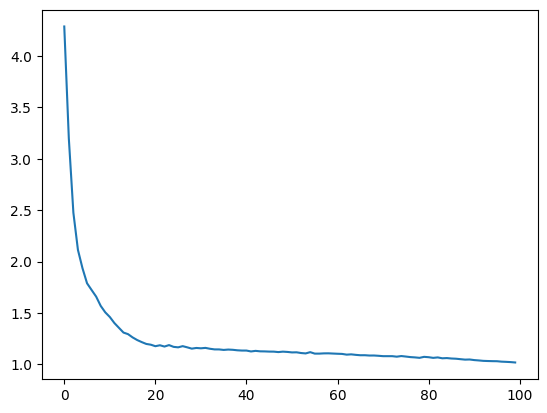

In [17]:
plt.plot(epoch_loss)
np.save("epoch_loss.npy", epoch_loss)

In [18]:
solver_net.eval()

test_dataset = TensorDataset(data.testX, data.testY)

test_loader = DataLoader(test_dataset, batch_size=len(test_dataset))

with torch.no_grad():
    for Xtest, Ytest in test_loader:

        Xtest = Xtest.to(DEVICE)
        Ytest = Ytest.to(DEVICE)

        Yhat_test_partial = solver_net(Xtest)

        Yhat_test_partial_trans = data.complete_partial_tanh(Xtest, Yhat_test_partial) #used to satisfy the voltage magnitude constraints

        Yhat_test = PFFunction_eval(data)(Xtest, Yhat_test_partial_trans)
    

In [20]:
pg_test, qg_test, vm_test, va_test = data.get_yvars(Yhat_test)

In [21]:
print(torch.mean(data.obj_fn(Yhat_test)))
print(torch.mean(data.obj_fn(data.testY)))
gap = 100 * torch.abs(torch.mean(data.obj_fn(Yhat_test)) - torch.mean(data.obj_fn(data.testY))) / torch.mean(data.obj_fn(data.testY))
print(gap)

tensor(10.1673)
tensor(10.0867)
tensor(0.7998)


In [22]:
print(torch.mean(torch.mean(data.ineq_dist(Xtest, Yhat_test), dim=1)))
print(torch.mean(torch.max(data.ineq_dist(Xtest, Yhat_test), dim=1)[0]))
print(np.mean(torch.sum(data.ineq_dist(Xtest, Yhat_test) > 0, dim=1).detach().numpy()))
print(100*(1 - np.mean(torch.sum(data.ineq_dist(Xtest, Yhat_test) > 0, dim=1).detach().numpy())/torch.sum(data.ineq_dist(Xtest, Yhat_test) > 0, dim=0).shape[0]))

tensor(6.8068e-06)
tensor(0.0031)
0.35
99.92256637168143


In [23]:
# check the VM violation
print(vm_test.shape)
lower_correct = (vm_test >= data.vmin)
upper_correct = (vm_test <= data.vmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(vm_test.shape[0] * vm_test.shape[1])
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(vm_test.shape[0] * vm_test.shape[1])
print(high_violation_ratio)

torch.Size([20, 118])
torch.Size([20, 118])
0.0
0.0


In [24]:
# check the Pg violation
print(pg_test.shape)
lower_correct = (pg_test >= data.pmin)
upper_correct = (pg_test <= data.pmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(pg_test.shape[0] * pg_test.shape[1])
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(pg_test.shape[0] * pg_test.shape[1])
print(high_violation_ratio)

torch.Size([20, 54])
torch.Size([20, 54])
0.0
0.0


In [25]:
# check the Qg violation
print(qg_test.shape)
lower_correct = (qg_test >= data.qmin)
upper_correct = (qg_test <= data.qmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(pg_test.shape[0] * pg_test.shape[1])
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(pg_test.shape[0] * pg_test.shape[1])
print(high_violation_ratio)

torch.Size([20, 54])
torch.Size([20, 54])
0.0018518518518518823
0.00462962962962965


In [26]:
# # check the Sij violation
# print(bf_test.shape)
# lower_correct = (bf_test >= 0)
# upper_correct = (bf_test <= data.bfmax)
# print(lower_correct.shape)
# low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(bf_test.shape[0] * bf_test.shape[1])
# print(low_violation_ratio)

# high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(bf_test.shape[0] * bf_test.shape[1])
# print(high_violation_ratio)

In [41]:
#equality 
equality_mismatch = data.eq_resid(Xtest, Yhat_test).detach()

print(torch.mean(torch.abs(equality_mismatch)))

print(torch.mean(torch.norm(equality_mismatch, dim=1)))


tensor(8.4414e-08)
tensor(3.5730e-06)


In [407]:
solver_net.eval()

test_dataset = TensorDataset(data.X[int((1-valid_frac-test_frac)*num):,:], data.Y[int((1-valid_frac-test_frac)*num):,:])

test_loader = DataLoader(test_dataset, batch_size=len(test_dataset))

start_time = time.time()

for Xtest, Ytest in test_loader:
    
    Xtest = Xtest.to(DEVICE)
    Ytest = Ytest.to(DEVICE)
    
    Yhat_test_partial = solver_net(Xtest)
        
    Yhat_test_partial_trans = data.complete_partial_tanh(Xtest, Yhat_test_partial) #used to satisfy the voltage magnitude constraints
        
    Yhat_test = PFFunction_eval(data)(Xtest, Yhat_test_partial_trans)

train_time = time.time() - start_time

In [408]:
pg_test, qg_test, vm_test, va_test, bf_test = data.get_yvars(Yhat_test)

In [417]:
# check the Sij violation
print(bf_test.shape)
lower_correct = (bf_test >= 0)
upper_correct = (bf_test <= data.bfmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(bf_test.shape[0] * bf_test.shape[1])
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(bf_test.shape[0] * bf_test.shape[1])
print(high_violation_ratio)

torch.Size([8281, 186])
torch.Size([8281, 186])
0.0
0.0035195219527016652


In [410]:
torch.norm(torch.clamp(bf_test - data.bfmax, 0),dim=0).nonzero()

tensor([[  6],
        [  7],
        [ 36],
        [ 37],
        [ 40],
        [ 50],
        [ 53],
        [ 70],
        [ 95],
        [ 96],
        [116],
        [118],
        [120],
        [124],
        [135],
        [182]])

In [414]:
bf_test[:, branch_nonbinding]

tensor([[3.0393, 2.5267, 0.2221,  ..., 0.2770, 0.2525, 3.0182],
        [3.0463, 2.9736, 0.2208,  ..., 0.2685, 0.2587, 2.8411],
        [3.0393, 2.8835, 0.2516,  ..., 0.2204, 0.2007, 3.0181],
        ...,
        [3.0554, 2.6173, 0.1987,  ..., 0.2352, 0.2180, 2.8253],
        [3.0516, 2.8501, 0.2312,  ..., 0.1780, 0.2006, 3.1238],
        [3.0616, 2.8289, 0.1943,  ..., 0.1415, 0.1912, 2.9451]],
       grad_fn=<IndexBackward0>)

In [416]:
data.bfmax[branch_nonbinding]

tensor([3.0976, 3.1684, 0.3844, 0.3969, 3.2041, 0.3844, 3.1329, 0.2500, 3.0976,
        0.3844, 0.3721, 0.3844, 0.3969, 0.3844, 3.1684, 3.2041, 3.0976, 3.1684,
        0.3844, 0.3844, 3.0976, 0.3844, 0.3969, 0.3721, 0.3721, 0.3969, 0.3721,
        3.2041, 0.3844, 0.3844, 3.2041])

In [420]:
torch.norm(torch.clamp(bf_test[:, branch_nonbinding] - data.bfmax[branch_nonbinding], 0),dim=0)

tensor([6.6132e-04, 1.1935e-02, 0.0000e+00, 0.0000e+00, 0.0000e+00, 8.5877e-02,
        1.9460e-01, 4.2307e-01, 6.3094e-01, 9.8204e-02, 0.0000e+00, 0.0000e+00,
        1.1186e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00, 6.9011e-02, 1.3285e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 1.5170e-01, 0.0000e+00, 2.0312e+00,
        1.3019e-01, 2.7812e-01, 5.6927e-02, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        3.0767e-01], grad_fn=<CopyBackwards>)

In [159]:
test_dataset_PP = TensorDataset(testX_new[:samplenumber,:], Yhat_test[:samplenumber,:])
opt_batch_size = 30
test_loader_PP = DataLoader(test_dataset_PP, batch_size=opt_batch_size)
Yhat_test_PP = torch.zeros(Yhat_test[:samplenumber,:].shape)
Yhat_partial_test_PP = torch.zeros(Yhat_test_partial_trans[:samplenumber,:].shape)

opt_step = 10
opt_lr = 0.00001
b = 0

In [160]:
# the first PP obly considers inequality constraints excluding input
start_time = time.time()
for Xtest_PP, Ytest_PP in test_loader_PP:
    Xtest_PP = Xtest_PP.to(DEVICE)
    Ytest_PP = Ytest_PP.to(DEVICE)
    pg_test, qg_test, vm_test, va_test, bf_test = data.get_yvars(Ytest_PP)
    Ytest_PP_partial = torch.cat([pg_test[:, data.pv_], vm_test[:, data.spv]], dim=1).clone().detach().requires_grad_(True)

    opt = optim.Adam([Ytest_PP_partial], lr = opt_lr)
    for i in range(opt_step):

        Yhat_test1 = PFFunction_PP(data)(Xtest_PP, Ytest_PP_partial)

        ineq_cost = torch.norm(data.ineq_dist1(Xtest_PP, Yhat_test1), dim=1).mean()
        
        opt.zero_grad()

        ineq_cost.backward()

        opt.step() 
        
    Yhat_partial_test_PP[b:b+opt_batch_size] = Ytest_PP_partial
    Yhat_test_PP[b:b+opt_batch_size] = Yhat_test1
    b = b + opt_batch_size
train_time = time.time() - start_time
print(train_time)

203.51206612586975


In [161]:
#original
print(torch.mean(torch.mean(data.ineq_dist(Xtest[:samplenumber,:], Yhat_test[:samplenumber,:]), dim=1)))
print(torch.mean(torch.max(data.ineq_dist(Xtest[:samplenumber,:], Yhat_test[:samplenumber,:]), dim=1)[0]))
print(torch.mean(data.obj_fn(Yhat_test[:samplenumber,:])))

tensor(7.7225e-05, grad_fn=<MeanBackward0>)
tensor(0.3090, grad_fn=<MeanBackward0>)
tensor(7.4057, grad_fn=<MeanBackward0>)


In [163]:
#original
print(torch.mean(torch.mean(data.ineq_dist(Xtest[:samplenumber,:], Yhat_test_PP[:samplenumber,:]), dim=1)))
print(torch.mean(torch.max(data.ineq_dist(Xtest[:samplenumber,:], Yhat_test_PP[:samplenumber,:]), dim=1)[0]))
print(torch.mean(data.obj_fn(Yhat_test[:samplenumber,:])))

tensor(6.4890e-05, grad_fn=<MeanBackward0>)
tensor(0.2842, grad_fn=<MeanBackward0>)
tensor(7.4057, grad_fn=<MeanBackward0>)


In [17]:
class NNSolver_eval(nn.Module):
    def __init__(self, data, args):
        super().__init__()
        self._data = data
        self._args = args
        
        output_dim = data.ydim - data.nknowns
        
        self.layers1 = nn.Linear(data.nbus*2, self._args['hiddenSize'])
        
        self.relu = nn.ReLU(inplace=True)
        
        self.layers2 = nn.Linear(self._args['hiddenSize'], data.npv*2+1)

        self.layers3 = nn.Linear(self._args['hiddenSize'], self._args['hiddenSize'])
        
    def forward(self, x):

        out = self.layers1(x)
        
        out = self.relu(out)

        out = self.layers3(out)
        
        out = self.relu(out)
        
        out = self.layers2(out)

#         out = nn.Tanh()(out)   # used to interpolate between max and min values

        return out

In [18]:
solver_net_eval = NNSolver_eval(data, args)
solver_net_eval.to(DEVICE)
savepath = os.path.join('data/super/hid50_soft01_fulllinear_equality_fulllinear_Super1_lr00001_supervised_epoch200.pth')
solver_net_eval.load_state_dict(torch.load(savepath))

Yhat_test_partial = solver_net_eval(testX_new)

In [19]:
Yhat_test_partial

tensor([[-10.6424,  -9.8475,   1.7286,  ...,   8.5091,   1.3531,   2.1856],
        [-10.4048,  -9.4726,   1.6913,  ...,   8.3767,   1.5658,   2.1167],
        [-10.5823,  -9.7873,   1.7198,  ...,   8.4288,   1.3093,   2.1656],
        ...,
        [-10.5490,  -9.7681,   1.7118,  ...,   8.4303,   1.3105,   2.1604],
        [-10.2811,  -9.4385,   1.6557,  ...,   8.2040,   1.3036,   2.0792],
        [-10.3292,  -9.4707,   1.6950,  ...,   8.4357,   1.6818,   2.1189]],
       grad_fn=<AddmmBackward0>)

In [20]:
samplenumber = testX_new.shape[0]
print(samplenumber)

800


In [21]:
# the second PP obly considers inequality constraints including input including sigmoid
test_dataset_PP3 = TensorDataset(testX_new, Yhat_test_partial)

opt_batch_size = 40
test_loader_PP3 = DataLoader(test_dataset_PP3, batch_size=opt_batch_size)

Yhat_partial_test_sig_PP3 = torch.zeros(Yhat_test_partial.shape) # partial set before sigmoid
Yhat_partial_test_PP3 = torch.zeros(Yhat_test_partial.shape) # partial set after sigmoid
Yhat_test_PP3 = torch.zeros(Yhat_test_partial.shape[0], Yhat_test.shape[1]) # full set 

opt_step = 5
opt_lr = 0.0001
b = 0

In [22]:
Yhat_test.shape

torch.Size([800, 5219])

In [30]:
# the first PP obly considers inequality constraints excluding input
start_time = time.time()
for Xtest_PP, Ytest_partial_PP in test_loader_PP3:
    Xtest_PP = Xtest_PP.to(DEVICE)
    Ytest_partial_PP = Ytest_partial_PP.to(DEVICE).clone().detach().requires_grad_(True)
    opt = optim.Adam([Ytest_partial_PP], lr = opt_lr)
    
    for i in range(opt_step):
        
        Ytest_partial_PP1 = nn.Tanh()(Ytest_partial_PP) 
        
        Yhat_test_partial_trans = data.complete_partial_tanh(Xtest_PP, Ytest_partial_PP1) 
        
        Yhat_test1 = PFFunction_PP(data)(Xtest_PP, Yhat_test_partial_trans)

        ineq_cost = torch.norm(data.ineq_dist1(Xtest_PP, Yhat_test1), dim=1).mean()

        opt.zero_grad()

        ineq_cost.backward()

        opt.step() 
        
    Yhat_partial_test_sig_PP3[b:b+opt_batch_size] = Ytest_partial_PP1
    Yhat_partial_test_PP3[b:b+opt_batch_size] = Yhat_test_partial_trans
    Yhat_test_PP3[b:b+opt_batch_size] = Yhat_test1
    b = b + opt_batch_size
train_time = time.time() - start_time
print(train_time)

tensor([[   0,  352],
        [   0,  384],
        [   0,  472],
        ...,
        [  39, 1813],
        [  39, 1820],
        [  39, 1868]])


KeyboardInterrupt: 

In [28]:
Xtest.nonzero()

tensor([[   0,    0],
        [   0,    1],
        [   0,    2],
        ...,
        [ 799, 2702],
        [ 799, 2705],
        [ 799, 2706]])

In [194]:
#original
print(torch.mean(torch.mean(data.ineq_dist(Xtest[:samplenumber,:], Yhat_test[:samplenumber,:]), dim=1)))
print(torch.mean(torch.max(data.ineq_dist(Xtest[:samplenumber,:], Yhat_test[:samplenumber,:]), dim=1)[0]))
print(torch.mean(data.obj_fn(Yhat_test[:samplenumber,:])))

tensor(7.2098e-05, grad_fn=<MeanBackward0>)
tensor(0.2853, grad_fn=<MeanBackward0>)
tensor(7.4006, grad_fn=<MeanBackward0>)


In [282]:
#original
print(torch.mean(torch.mean(data.ineq_dist(Xtest[:samplenumber,:], Yhat_test_PP3[:samplenumber,:]), dim=1)))
print(torch.mean(torch.max(data.ineq_dist(Xtest[:samplenumber,:], Yhat_test_PP3[:samplenumber,:]), dim=1)[0]))
print(torch.mean(data.obj_fn(Yhat_test_PP3[:samplenumber,:])))

tensor(6.2182e-05, grad_fn=<MeanBackward0>)
tensor(0.2638, grad_fn=<MeanBackward0>)
tensor(7.4006, grad_fn=<MeanBackward0>)


In [287]:
Yhat_test_PP3[:samplenumber,:].shape

torch.Size([800, 5219])

In [300]:
pg_test_PP3, qg_test_PP3, vm_test_PP3, va_test_PP3, bf_test_PP3 = data.get_yvars(Yhat_test_PP3[:samplenumber,:])

In [301]:
# check the Pg violation
print(pg_test_PP3.shape)
lower_correct = (pg_test_PP3 >= data.pmin)
upper_correct = (pg_test_PP3 <= data.pmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(lower_correct.shape[0] * lower_correct.shape[1])
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(upper_correct.shape[0] * upper_correct.shape[1])
print(high_violation_ratio)

torch.Size([800, 260])
torch.Size([800, 260])
0.0005432692307691944
0.0


In [302]:
# check the Qg violation
print(qg_test_PP3.shape)
lower_correct = (qg_test_PP3 >= data.qmin)
upper_correct = (qg_test_PP3 <= data.qmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(pg_test_PP3.shape[0] * pg_test.shape[1])
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(pg_test_PP3.shape[0] * pg_test.shape[1])
print(high_violation_ratio)

torch.Size([800, 260])
torch.Size([800, 260])
0.003937500000000038
0.006774038461538456


In [304]:
# check the Sij violation
print(bf_test_PP3.shape)
lower_correct = (bf_test_PP3 >= 0)
upper_correct = (bf_test_PP3 <= data.bfmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(bf_test_PP3.shape[0] * bf_test_PP3.shape[1])
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(bf_test_PP3.shape[0] * bf_test_PP3.shape[1])
print(high_violation_ratio)

torch.Size([800, 1991])
torch.Size([800, 1991])
0.0
1.1300853842266534e-05


In [29]:
def PFFunction_PP(data, tol=1e-5, bsz=20, bsz2=20, max_iters=30):
    class PFFunctionFn_PP(Function):
        @staticmethod
        def forward(ctx, X, Z):

            ## Step 1: Newton's method
            Y = torch.zeros(X.shape[0], data.ydim, device=data.device, dtype=torch.get_default_dtype())
            # known/estimated values (pg at pv buses, vm at all gens, va at slack bus)
            Y[:, data.pg_start_yidx + data.pv_] = Z[:, data.pg_pv_zidx]    # pg at non-slack gens
            Y[:, data.vm_start_yidx + data.spv] = Z[:, data.vm_spv_zidx]   # vm at gens
            Y[:, data.va_start_yidx + data.slack] = torch.tensor(data.slack_va, device=data.device, dtype=torch.get_default_dtype())  # va at slack bus
            # init guesses for remaining values
            Y[:, data.vm_start_yidx + data.pq] = torch.tensor(data.vm_init[data.pq], device=data.device, dtype=torch.get_default_dtype())  # vm at load buses
            Y[:, data.va_start_yidx + data.pv] = torch.tensor(data.va_init[data.pv], device=data.device, dtype=torch.get_default_dtype())  # va at non-slack gens 
            Y[:, data.va_start_yidx + data.pq] = torch.tensor(data.va_init[data.pq], device=data.device, dtype=torch.get_default_dtype())  # va at load buses
           
            Y[:, data.qg_start_yidx:data.qg_start_yidx+data.ng] = 0    # qg at gens (not used in Newton upd)
            Y[:, data.pg_start_yidx+data.slack_] = 0                   # pg at slack (not used in Newton upd)
            Y[:, data.bf_start_yidx:] = 0                   # sij at all buses (not used in Newton upd)

            keep_constr = np.concatenate([
                data.pflow_start_eqidx + data.pv,     # real power flow at non-slack gens
                data.pflow_start_eqidx + data.pq,     # real power flow at load buses
                data.qflow_start_eqidx + data.pq])    # reactive power flow at load buses

            newton_guess_inds = np.concatenate([             
                data.vm_start_yidx + data.pq,         # vm at load buses
                data.va_start_yidx + data.pv,         # va at non-slack gens
                data.va_start_yidx + data.pq])        # va at load buses
            
            keep_constr1 = np.concatenate([
                data.pflow_start_eqidx + data.pv,     # real power flow at non-slack gens
                data.pflow_start_eqidx + data.pq])     # real power flow at load buses
            
            keep_constr2 = data.qflow_start_eqidx + data.pq    # reactive power flow at load buses
            
            newton_guess_inds1 = np.concatenate([             
                data.va_start_yidx + data.pv,         # va at non-slack gens
                data.va_start_yidx + data.pq])        # va at load buses
            
            newton_guess_inds2 = data.vm_start_yidx + data.pq         # vm at load buses

            last_eqs = np.concatenate([data.pflow_start_eqidx + data.slack, data.qflow_start_eqidx + data.spv])
#             converged = torch.zeros(X.shape[0])
            jacs = []
            jac2s = []
            jac3s = []
            newton_jacs_inv = []
            bf_grad = []
                
            for b in range(0, X.shape[0], bsz):
                # print('batch: {}'.format(b))
                X_b = X[b:b+bsz]
                Y_b = Y[b:b+bsz]

                _, _, vm, va, _ = data.get_yvars(Y_b) 

                mis = data.eq_resid(X_b, Y_b) 
                
                newton_Bp_inv = data.Bp.expand(mis.shape[0], *data.Bp.shape)
                newton_Bpp_inv = data.Bpp.expand(mis.shape[0], *data.Bpp.shape)
                
                gy1 = mis[:, keep_constr1] / vm[:, np.concatenate([data.pv, data.pq])]  # calculate P mismatch
                gy2 = mis[:, keep_constr2] / vm[:, data.pq]  # calculate Q mismatch
                     
                for i in range(max_iters):
                
                    Va_delta = -newton_Bp_inv.bmm(gy1.unsqueeze(-1)).squeeze(-1)

                    Y_b[:, newton_guess_inds1] -= Va_delta # update the voltage angle 
        
                    _, _, vm, va, _ = data.get_yvars(Y_b) # evalute mismatch
            
                    mis = data.eq_resid(X_b, Y_b) 
                    gy1 = mis[:, keep_constr1] / vm[:, np.concatenate([data.pv, data.pq])]  # calculate P mismatch
                    gy2 = mis[:, keep_constr2] / vm[:, data.pq]  # calculate Q mismatch
                    
                    if torch.norm(gy1, dim=1).abs().max() < tol and torch.norm(gy2, dim=1).abs().max() < tol:
                        break

                    Vm_delta = -newton_Bpp_inv.bmm(gy2.unsqueeze(-1)).squeeze(-1)

                    Y_b[:, newton_guess_inds2] -= Vm_delta  # update the voltage magnitude
                    
                    _, _, vm, va, _ = data.get_yvars(Y_b) # evalute mismatch
                    mis = data.eq_resid(X_b, Y_b)
                    gy1 = mis[:, keep_constr1] / vm[:, np.concatenate([data.pv, data.pq])]  # calculate P mismatch
                    gy2 = mis[:, keep_constr2] / vm[:, data.pq]  # calculate Q mismatch

                    if torch.norm(gy1, dim=1).abs().max() < tol and torch.norm(gy2, dim=1).abs().max() < tol:
                        break
                    
                jac_full = data.eq_jac_LR_full(Y_b, Weights_equality_linear_full) 
                # jacs.append(jac_full)
                jac3s.append(jac_full[:, last_eqs, data.vm_start_yidx:])
                jac2s.append(jac_full[:, keep_constr, :])
                ## Step 2: Solve for remaining variables
#                 equality_resid_b = -data.eq_resid(X_b, Y_b)

                Y_b[:, data.qg_start_yidx:data.qg_start_yidx + data.ng] = -mis[:, data.qflow_start_eqidx + data.spv]

                Y_b[:, data.pg_start_yidx + data.slack_] = -mis[:, data.pflow_start_eqidx + data.slack]

                # calculate the branch flow  
                
                Pf, Qf = data.eq_resid_bf(X_b, Y_b)
                Y_b[:, data.bf_start_yidx:] = torch.square(Pf) + torch.square(Qf)
                
                eq_jac_tmp = data.eq_jac_pfqf_LR_full(Y_b, WeightMatrix_linear_full)
                eq_jac_bf_tmp = data.eq_jac_bf_modi2(Y_b, Pf, Qf, eq_jac_tmp)
                bf_grad_b = data.eq_jac_bf_modi3(Y_b, eq_jac_bf_tmp)
                bf_grad.append(bf_grad_b.to(torch.get_default_dtype()))
            
            ctx.data = data

            ctx.save_for_backward(torch.cat(jac2s), torch.cat(jac3s),
                torch.tensor(newton_guess_inds, device = data.device), 
                torch.tensor(keep_constr, device = data.device), torch.cat(bf_grad))
            
            return Y

        @staticmethod
        def backward(ctx, dl_dy):
            data = ctx.data
            # jac, newton_guess_inds, keep_constr, bf_grad = ctx.saved_tensors
            jac2, jac3, newton_guess_inds, keep_constr, bf_grad = ctx.saved_tensors
            ## Step 2 (calc pg at slack and qg at gens)

            # gradient of all voltages through step 3 outputs, for Z_2
            last_eqs = np.concatenate([data.pflow_start_eqidx + data.slack, data.qflow_start_eqidx + data.spv])
            last_vars = np.concatenate([
                data.pg_start_yidx + data.slack_, np.arange(data.qg_start_yidx, data.qg_start_yidx + data.ng)])
            # jac3 = jac[:, last_eqs, :]
            
            dl_dvmva_3 = -jac3.transpose(1,2).bmm(
                dl_dy[:, last_vars].unsqueeze(-1)).squeeze(-1)

            dl_dvmva_4 = bf_grad.transpose(1,2).bmm(
                dl_dy[:, -data.nbr:].unsqueeze(-1)).squeeze(-1)
            
            # gradient of pd at slack and qd at gens through step 3 outputs
            dl_dpdqd_3 = dl_dy[:, last_vars]

            # insert into correct places in x and y loss vectors
            dl_dy_3 = torch.zeros(dl_dy.shape, device = data.device)
            dl_dy_3[:, data.vm_start_yidx:-data.nbr] = dl_dvmva_3

            # insert into correct places in x and y loss vectors
            dl_dy_4 = torch.zeros(dl_dy.shape, device = data.device)
            dl_dy_4[:, data.vm_start_yidx:-data.nbr] = dl_dvmva_4

#             dl_dx_3 = torch.zeros(dl_dy.shape[0], data.xdim, device = data.device)
#             dl_dx_3[:, np.concatenate([data.slack, data.nbus + data.spv])] = dl_dpdqd_3

            ## Step 1
            dl_dy_total = dl_dy_4 + dl_dy_3 + dl_dy  # Backward pass vector including result of last step

            # Use precomputed inverse jacobian
            # jac2 = jac[:, keep_constr, :]

            jac_newton = jac2[:, :, newton_guess_inds].transpose(1,2)

            d_int = torch.zeros(dl_dy_total[:,newton_guess_inds].shape, device = data.device)

            for b in range(0, dl_dy_total.shape[0], bsz2):
                dl_dy_total_b = dl_dy_total[b:b+bsz2]
                jac_newton_b = jac_newton[b:b+bsz2]
                d_int_b = torch.linalg.solve(jac_newton_b, dl_dy_total_b[:, newton_guess_inds]).to(data.device)
                d_int[b:b+bsz2] = d_int_b
            
            dl_dz_2 = torch.zeros(dl_dy.shape[0], data.npv + data.ng, device = data.device)
            dl_dz_2[:, data.pg_pv_zidx] = -d_int[:, :data.npv]  # dl_dpg at pv buses
            dl_dz_2[:, data.vm_spv_zidx] = -jac2[:, :, data.vm_start_yidx + data.spv].transpose(1,2).bmm(
                d_int.unsqueeze(-1)).squeeze(-1)

#             dl_dx_2 = torch.zeros(dl_dy.shape[0], data.xdim, device = data.device)
#             dl_dx_2[:, data.pv] = d_int[:, :data.npv]                       # dl_dpd at pv buses
#             dl_dx_2[:, data.pq] = d_int[:, data.npv:data.npv+len(data.pq)]  # dl_dpd at pq buses
#             dl_dx_2[:, data.nbus + data.pq] = d_int[:, -len(data.pq):]      # dl_dqd at pq buses

            # Final quantities
#             dl_dx_total = dl_dx_3 + dl_dx_2
            dl_dz_total = dl_dz_2 + dl_dy_total[:, np.concatenate([
                data.pg_start_yidx + data.pv_, data.vm_start_yidx + data.spv])]

            return None, dl_dz_total


    return PFFunctionFn_PP.apply

In [615]:
class NNSolver_PP(nn.Module):
    def __init__(self, data, args):
        super().__init__()
        self._data = data
        self._args = args
        
        output_dim = data.ydim - data.nknowns
        
        self.layers1 = nn.Linear(data.nbus*2, self._args['hiddenSize'])
        
        self.relu = nn.ReLU(inplace=True)
        
        self.layers2 = nn.Linear(self._args['hiddenSize'], data.ng + 1 + data.nbr*2)

        self.layers3 = nn.Linear(self._args['hiddenSize'], self._args['hiddenSize'])
        
    def forward(self, x):

        out = self.layers1(x)
        
        out = self.relu(out)

        out = self.layers3(out)
        
        out = self.relu(out)
        
        out = self.layers2(out)
        
        return out

In [616]:
solver_net_PP = NNSolver_PP(data, args)
solver_net_PP.to(DEVICE)
# solver_net_PP.eval()
savepath = os.path.join('data/super/solver_net_stage2_samples.pth')
solver_net_PP.load_state_dict(torch.load(savepath))

<All keys matched successfully>

In [609]:
Yhat_test_partial

tensor([[-1.0000, -1.0000,  0.9389,  ...,  1.0000,  0.8748,  0.9750],
        [-1.0000, -1.0000,  0.9343,  ...,  1.0000,  0.9164,  0.9714],
        [-1.0000, -1.0000,  0.9378,  ...,  1.0000,  0.8641,  0.9740],
        ...,
        [-1.0000, -1.0000,  0.9369,  ...,  1.0000,  0.8644,  0.9738],
        [-1.0000, -1.0000,  0.9296,  ...,  1.0000,  0.8627,  0.9692],
        [-1.0000, -1.0000,  0.9348,  ...,  1.0000,  0.9331,  0.9715]],
       grad_fn=<TanhBackward0>)

In [617]:
Yhat_test = Yhat_test.to(DEVICE).clone().detach().requires_grad_(True)

In [618]:
Yhat_NN = solver_net_PP(Yhat_test) # pslack, qg, pf, qf

In [612]:
Yhat_NN

tensor([[21.2952, -1.4190, -0.2111,  ...,  0.4189,  0.4309,  0.5196],
        [18.5987, -1.4517, -0.2210,  ...,  0.4194,  0.4354,  0.5325],
        [19.6586, -1.4207, -0.2780,  ...,  0.4241,  0.4374,  0.5191],
        ...,
        [15.4961, -1.4498, -0.1472,  ...,  0.4215,  0.4337,  0.5241],
        [16.9232, -1.4378, -0.1750,  ...,  0.4219,  0.4352,  0.5311],
        [15.0613, -1.4643, -0.2530,  ...,  0.4102,  0.4343,  0.5138]],
       grad_fn=<AddmmBackward0>)

In [619]:
torch.autograd.grad(test_loss, Xtest)

In [633]:
# the second PP obly considers inequality constraints including input including sigmoid
test_dataset_PP3 = TensorDataset(testX_new, Yhat_test_partial)

opt_batch_size = 40
test_loader_PP3 = DataLoader(test_dataset_PP3, batch_size=opt_batch_size)

Yhat_partial_test_sig_PP3 = torch.zeros(Yhat_test_partial.shape) # partial set before sigmoid
Yhat_partial_test_PP3 = torch.zeros(Yhat_test_partial.shape) # partial set after sigmoid
Yhat_test_PP3 = torch.zeros(Yhat_test_partial.shape[0], Yhat_test.shape[1]) # full set 

opt_step = 5
opt_lr = 0.0001
b = 0

In [635]:
# the first PP obly considers inequality constraints excluding input
start_time = time.time()
for Xtest_PP, Ytest_partial_PP in test_loader_PP3:
    Xtest_PP = Xtest_PP.to(DEVICE)
    Ytest_partial_PP = Ytest_partial_PP.to(DEVICE).clone().detach().requires_grad_(True)
    opt = optim.Adam([Ytest_partial_PP], lr = opt_lr)
    
    for i in range(opt_step):
        
        Ytest_partial_PP1 = nn.Tanh()(Ytest_partial_PP) 
        
        Yhat_test_partial_trans = data.complete_partial_tanh(Xtest_PP, Ytest_partial_PP1) 
        
        Yhat_test1 = PFFunction_PP(data)(Xtest_PP, Yhat_test_partial_trans)

        ineq_cost = torch.norm(data.ineq_dist1(Xtest_PP, Yhat_test1), dim=1).mean()

        opt.zero_grad()

        ineq_cost.backward()
        
        opt.step() 
        
    Yhat_partial_test_sig_PP3[b:b+opt_batch_size] = Ytest_partial_PP1
    Yhat_partial_test_PP3[b:b+opt_batch_size] = Yhat_test_partial_trans
    Yhat_test_PP3[b:b+opt_batch_size] = Yhat_test1
    b = b + opt_batch_size
train_time = time.time() - start_time
print(train_time)

torch.Size([40, 2708, 261])
torch.Size([40, 2708])
torch.Size([40, 2708])


KeyboardInterrupt: 

In [573]:
#original
print(torch.mean(torch.mean(data.ineq_dist(Xtest[:samplenumber,:], Yhat_test_PP3[:samplenumber,:]), dim=1)))
print(torch.mean(torch.max(data.ineq_dist(Xtest[:samplenumber,:], Yhat_test_PP3[:samplenumber,:]), dim=1)[0]))
print(torch.mean(data.obj_fn(Yhat_test_PP3[:samplenumber,:])))

tensor(0.0018, grad_fn=<MeanBackward0>)
tensor(2.6772, grad_fn=<MeanBackward0>)
tensor(7.4155, grad_fn=<MeanBackward0>)


In [634]:
def PFFunction_PP(data, tol=1e-5, bsz=20, bsz2=20, max_iters=30):
    class PFFunctionFn_PP(Function):
        @staticmethod
        def forward(ctx, X, Z):

            ## Step 1: Newton's method
            Y = torch.zeros(X.shape[0], data.ydim, device=data.device, dtype=torch.get_default_dtype())
            # known/estimated values (pg at pv buses, vm at all gens, va at slack bus)
            Y[:, data.pg_start_yidx + data.pv_] = Z[:, data.pg_pv_zidx]    # pg at non-slack gens
            Y[:, data.vm_start_yidx + data.spv] = Z[:, data.vm_spv_zidx]   # vm at gens
            Y[:, data.va_start_yidx + data.slack] = torch.tensor(data.slack_va, device=data.device, dtype=torch.get_default_dtype())  # va at slack bus
            # init guesses for remaining values
            Y[:, data.vm_start_yidx + data.pq] = torch.tensor(data.vm_init[data.pq], device=data.device, dtype=torch.get_default_dtype())  # vm at load buses
            Y[:, data.va_start_yidx + data.pv] = torch.tensor(data.va_init[data.pv], device=data.device, dtype=torch.get_default_dtype())  # va at non-slack gens 
            Y[:, data.va_start_yidx + data.pq] = torch.tensor(data.va_init[data.pq], device=data.device, dtype=torch.get_default_dtype())  # va at load buses
           
            Y[:, data.qg_start_yidx:data.qg_start_yidx+data.ng] = 0    # qg at gens (not used in Newton upd)
            Y[:, data.pg_start_yidx+data.slack_] = 0                   # pg at slack (not used in Newton upd)
            Y[:, data.bf_start_yidx:] = 0                   # sij at all buses (not used in Newton upd)

            keep_constr = np.concatenate([
                data.pflow_start_eqidx + data.pv,     # real power flow at non-slack gens
                data.pflow_start_eqidx + data.pq,     # real power flow at load buses
                data.qflow_start_eqidx + data.pq])    # reactive power flow at load buses

            newton_guess_inds = np.concatenate([             
                data.vm_start_yidx + data.pq,         # vm at load buses
                data.va_start_yidx + data.pv,         # va at non-slack gens
                data.va_start_yidx + data.pq])        # va at load buses
            
            keep_constr1 = np.concatenate([
                data.pflow_start_eqidx + data.pv,     # real power flow at non-slack gens
                data.pflow_start_eqidx + data.pq])     # real power flow at load buses
            
            keep_constr2 = data.qflow_start_eqidx + data.pq    # reactive power flow at load buses
            
            newton_guess_inds1 = np.concatenate([             
                data.va_start_yidx + data.pv,         # va at non-slack gens
                data.va_start_yidx + data.pq])        # va at load buses
            
            newton_guess_inds2 = data.vm_start_yidx + data.pq         # vm at load buses

            last_eqs = np.concatenate([data.pflow_start_eqidx + data.slack, data.qflow_start_eqidx + data.spv])
#             converged = torch.zeros(X.shape[0])
            jacs = []
            jac2s = []
            jac3s = []
            newton_jacs_inv = []
            bf_grad = []
                
            for b in range(0, X.shape[0], bsz):
                # print('batch: {}'.format(b))
                X_b = X[b:b+bsz]
                Y_b = Y[b:b+bsz]

                _, _, vm, va, _ = data.get_yvars(Y_b) 

                mis = data.eq_resid(X_b, Y_b) 
                
                newton_Bp_inv = data.Bp.expand(mis.shape[0], *data.Bp.shape)
                newton_Bpp_inv = data.Bpp.expand(mis.shape[0], *data.Bpp.shape)
                
                gy1 = mis[:, keep_constr1] / vm[:, np.concatenate([data.pv, data.pq])]  # calculate P mismatch
                gy2 = mis[:, keep_constr2] / vm[:, data.pq]  # calculate Q mismatch
                     
                for i in range(max_iters):
                
                    Va_delta = -newton_Bp_inv.bmm(gy1.unsqueeze(-1)).squeeze(-1)

                    Y_b[:, newton_guess_inds1] -= Va_delta # update the voltage angle 
        
                    _, _, vm, va, _ = data.get_yvars(Y_b) # evalute mismatch
            
                    mis = data.eq_resid(X_b, Y_b) 
                    gy1 = mis[:, keep_constr1] / vm[:, np.concatenate([data.pv, data.pq])]  # calculate P mismatch
                    gy2 = mis[:, keep_constr2] / vm[:, data.pq]  # calculate Q mismatch
                    
                    if torch.norm(gy1, dim=1).abs().max() < tol and torch.norm(gy2, dim=1).abs().max() < tol:
                        break

                    Vm_delta = -newton_Bpp_inv.bmm(gy2.unsqueeze(-1)).squeeze(-1)

                    Y_b[:, newton_guess_inds2] -= Vm_delta  # update the voltage magnitude
                    
                    _, _, vm, va, _ = data.get_yvars(Y_b) # evalute mismatch
                    mis = data.eq_resid(X_b, Y_b)
                    gy1 = mis[:, keep_constr1] / vm[:, np.concatenate([data.pv, data.pq])]  # calculate P mismatch
                    gy2 = mis[:, keep_constr2] / vm[:, data.pq]  # calculate Q mismatch

                    if torch.norm(gy1, dim=1).abs().max() < tol and torch.norm(gy2, dim=1).abs().max() < tol:
                        break
                    
                jac_full = data.eq_jac_LR_full(Y_b, Weights_equality_linear_full) 
                # jacs.append(jac_full)
                jac3s.append(jac_full[:, last_eqs, data.vm_start_yidx:])
                jac2s.append(jac_full[:, keep_constr, :])
                ## Step 2: Solve for remaining variables
#                 equality_resid_b = -data.eq_resid(X_b, Y_b)

                Y_b[:, data.qg_start_yidx:data.qg_start_yidx + data.ng] = -mis[:, data.qflow_start_eqidx + data.spv]

                Y_b[:, data.pg_start_yidx + data.slack_] = -mis[:, data.pflow_start_eqidx + data.slack]

                # calculate the branch flow  
                
                Pf, Qf = data.eq_resid_bf(X_b, Y_b)
                Y_b[:, data.bf_start_yidx:] = torch.square(Pf) + torch.square(Qf)
                
                eq_jac_tmp = data.eq_jac_pfqf_LR_full(Y_b, WeightMatrix_linear_full)
                eq_jac_bf_tmp = data.eq_jac_bf_modi2(Y_b, Pf, Qf, eq_jac_tmp)
                bf_grad_b = data.eq_jac_bf_modi3(Y_b, eq_jac_bf_tmp)
                bf_grad.append(bf_grad_b.to(torch.get_default_dtype()))
            
            ctx.data = data

            ctx.save_for_backward(torch.cat(jac2s), torch.cat(jac3s),
                torch.tensor(newton_guess_inds, device = data.device), 
                torch.tensor(keep_constr, device = data.device), torch.cat(bf_grad))
            
            return Y

        @staticmethod
        def backward(ctx, dl_dy):
            
            data = ctx.data
            # jac, newton_guess_inds, keep_constr, bf_grad = ctx.saved_tensors
            jac2, jac3, newton_guess_inds, keep_constr, bf_grad = ctx.saved_tensors
            ## Step 2 (calc pg at slack and qg at gens)

            # gradient of all voltages through step 3 outputs, for Z_2
            last_eqs = np.concatenate([data.pflow_start_eqidx + data.slack, data.qflow_start_eqidx + data.spv])
            last_vars = np.concatenate([
                data.pg_start_yidx + data.slack_, np.arange(data.qg_start_yidx, data.qg_start_yidx + data.ng)])
            # jac3 = jac[:, last_eqs, :]
            print(jac3.transpose(1,2).shape)
            dl_dvmva_3 = -jac3.transpose(1,2).bmm(
                dl_dy[:, last_vars].unsqueeze(-1)).squeeze(-1)

            dl_dvmva_4 = bf_grad.transpose(1,2).bmm(
                dl_dy[:, -data.nbr:].unsqueeze(-1)).squeeze(-1)
            
            # gradient of pd at slack and qd at gens through step 3 outputs
            dl_dpdqd_3 = dl_dy[:, last_vars]

            # insert into correct places in x and y loss vectors
            dl_dy_3 = torch.zeros(dl_dy.shape, device = data.device)
            dl_dy_3[:, data.vm_start_yidx:-data.nbr] = dl_dvmva_3
    
            # insert into correct places in x and y loss vectors
            dl_dy_4 = torch.zeros(dl_dy.shape, device = data.device)
            dl_dy_4[:, data.vm_start_yidx:-data.nbr] = dl_dvmva_4
            
            print(dl_dvmva_3.shape)
            print(dl_dvmva_4.shape)
#             dl_dx_3 = torch.zeros(dl_dy.shape[0], data.xdim, device = data.device)
#             dl_dx_3[:, np.concatenate([data.slack, data.nbus + data.spv])] = dl_dpdqd_3

            ## Step 1
            dl_dy_total = dl_dy_4 + dl_dy_3 + dl_dy  # Backward pass vector including result of last step

            # Use precomputed inverse jacobian
            # jac2 = jac[:, keep_constr, :]

            jac_newton = jac2[:, :, newton_guess_inds].transpose(1,2)

            d_int = torch.zeros(dl_dy_total[:,newton_guess_inds].shape, device = data.device)

            for b in range(0, dl_dy_total.shape[0], bsz2):
                dl_dy_total_b = dl_dy_total[b:b+bsz2]
                jac_newton_b = jac_newton[b:b+bsz2]
                d_int_b = torch.linalg.solve(jac_newton_b, dl_dy_total_b[:, newton_guess_inds]).to(data.device)
                d_int[b:b+bsz2] = d_int_b
            
            dl_dz_2 = torch.zeros(dl_dy.shape[0], data.npv + data.ng, device = data.device)
            dl_dz_2[:, data.pg_pv_zidx] = -d_int[:, :data.npv]  # dl_dpg at pv buses
            dl_dz_2[:, data.vm_spv_zidx] = -jac2[:, :, data.vm_start_yidx + data.spv].transpose(1,2).bmm(
                d_int.unsqueeze(-1)).squeeze(-1)

            dl_dz_total = dl_dz_2 + dl_dy_total[:, np.concatenate([
                data.pg_start_yidx + data.pv_, data.vm_start_yidx + data.spv])]

            return None, dl_dz_total


    return PFFunctionFn_PP.apply

In [416]:
#post-processing for Pg/Qg discard, does not work
pg_test, qg_test, vm_test, va_test, bf_test = data.get_yvars(Yhat_test)

In [399]:
pg_test[:, data.pv_] = torch.clamp(pg_test[:, data.pv_], min = data.pmin[data.pv_], max = data.pmax[data.pv_])

In [400]:
qg_test[:, data.pv_] = torch.clamp(qg_test[:, data.pv_], min = data.qmin[data.pv_], max = data.qmax[data.pv_])

In [401]:
PgQg_test = torch.cat((pg_test[:, data.pv_], qg_test[:, data.pv_], vm_test[:, data.slack]), dim=1)
# build the full set of the random variable
print(PgQg_test.shape)
print(Xtest.shape)

torch.Size([800, 519])
torch.Size([800, 2708])


In [423]:
# Yhat_test_PgQg = PFFunction_pgqg(data)(Xtest[:100,:], PgQg_test[:100,:])

In [421]:
# def PFFunction_pgqg(data, tol=1e-5, bsz=20, bsz2=20, max_iters=30):
#     class PFFunctionFn_pgqg(Function):
#         @staticmethod
#         def forward(ctx, X, Z):

#             ## Step 1: Newton's method
#             Y = torch.zeros(X.shape[0], data.ydim, device=data.device, dtype=torch.get_default_dtype())
            
#             # known/estimated values (pg at pv buses, vm at all gens, va at slack bus)
#             Y[:, data.pg_start_yidx + data.pv_] = Z[:, data.pg_zidx]   # pg at all gens
#             Y[:, data.qg_start_yidx + data.pv_] = Z[:, data.qg_zidx]   # qg at all gens
#             Y[:, data.vm_start_yidx + data.slack] = Z[:, -1:]   # vm at slack bus
#             print(Y[:, data.pg_start_yidx + data.pv_] )
#             print(Y[:, data.qg_start_yidx + data.pv_])
#             print(Y[:, data.vm_start_yidx + data.slack])
#             # init guesses for the slack bus
#             Y[:, data.va_start_yidx + data.slack] = torch.tensor(data.slack_va, device=data.device)  # va at slack bus
            
#             # init guesses for remaining buses
#             Y[:, data.vm_start_yidx + data.nonslack_idxes] = torch.tensor(data.vm_init[data.nonslack_idxes], device=data.device)   # vm at load buses
#             Y[:, data.va_start_yidx + data.nonslack_idxes] = torch.tensor(data.va_init[data.nonslack_idxes], device=data.device)  # va at non-slack gens 

#             keep_constr = np.concatenate([
#                 data.pflow_start_eqidx + data.nonslack_idxes,  # real power flow at all non-slack buses 
#                 data.qflow_start_eqidx + data.nonslack_idxes]) # reactive power flow at all non-slack buses 
            
#             newton_guess_inds = np.concatenate([             
#                 data.vm_start_yidx + data.nonslack_idxes,   # vm at non-slack buses
#                 data.va_start_yidx + data.nonslack_idxes])  # va at non-slack buses
            
#             keep_constr1 = data.pflow_start_eqidx + data.nonslack_idxes # real power flow at non-slack gens

#             keep_constr2 = data.qflow_start_eqidx + data.nonslack_idxes   # reactive power flow at all buses
            
#             newton_guess_inds1 = data.va_start_yidx + data.nonslack_idxes # va at non-slack buses

#             newton_guess_inds2 = data.vm_start_yidx + data.nonslack_idxes  # vm at all buses

#             last_eqs = np.concatenate([data.pflow_start_eqidx + data.slack, data.qflow_start_eqidx + data.slack])
# #             converged = torch.zeros(X.shape[0])
#             jacs = []
#             jac2s = []
#             jac3s = []
#             newton_jacs_inv = []
#             bf_grad = []
            
#             for b in range(0, X.shape[0], bsz):
#                 # print('batch: {}'.format(b))
#                 X_b = X[b:b+bsz]
#                 Y_b = Y[b:b+bsz]
#                 #initial mismatch
#                 gy_all = data.eq_resid(X_b, Y_b)
#                 print(torch.norm(gy_all[:, keep_constr]))
#                 for i in range(max_iters):
#                     print(i)
#                     gy = gy_all[:, keep_constr]
#                     jac_full = data.eq_jac(Y_b)
#                     jac = jac_full[:, keep_constr, :]
#                     newton_jac_inv = torch.inverse(jac[:, :, newton_guess_inds])
#                     delta = newton_jac_inv.bmm(gy.unsqueeze(-1)).squeeze(-1)
#                     Y_b[:, newton_guess_inds] -= delta
# #                     Y_b[:, data.vm_start_yidx + data.nonslack_idxes] = torch.clamp(Y_b[:, data.vm_start_yidx + data.nonslack_idxes], lower, upper)
#                     gy_all = data.eq_resid(X_b, Y_b)   
#                     print(torch.norm(gy_all[:, keep_constr]))
#                     if torch.norm(gy_all[:, keep_constr]) < tol:
#                         break
                
#                 ## Step 2: Solve for remaining variables
#                 Y_b[:, data.pg_start_yidx + data.slack_] = -gy_all[:, data.pflow_start_eqidx + data.slack]   
#                 # calculate the branch flow            
#                 Pf, Qf = data.eq_resid_bf(X, Y)
                
#                 Y[:, data.bf_start_yidx:] = torch.square(Pf) + torch.square(Qf)
            
#             return Y

#     return PFFunctionFn_pgqg.apply

In [403]:
# def PFFunction_pgqg(data, tol=1e-5, bsz=20, bsz2=20, max_iters=30):
#     class PFFunctionFn_pgqg(Function):
#         @staticmethod
#         def forward(ctx, X, Z):

#             ## Step 1: Newton's method
#             Y = torch.zeros(X.shape[0], data.ydim, device=data.device, dtype=torch.get_default_dtype())
            
#             # known/estimated values (pg at pv buses, vm at all gens, va at slack bus)
#             Y[:, data.pg_start_yidx + data.pv_] = Z[:, data.pg_zidx]   # pg at all gens
#             Y[:, data.qg_start_yidx + data.pv_] = Z[:, data.qg_zidx]   # qg at all gens
#             Y[:, data.vm_start_yidx + data.slack] = Z[:, -1:]   # vm at slack bus
            
#             # init guesses for the slack bus
#             Y[:, data.va_start_yidx + data.slack] = torch.tensor(data.slack_va, device=data.device)  # va at slack bus
            
#             # init guesses for remaining buses
#             Y[:, data.vm_start_yidx + data.nonslack_idxes] = torch.tensor(data.vm_init[data.nonslack_idxes], device=data.device)   # vm at load buses
#             Y[:, data.va_start_yidx + data.nonslack_idxes] = torch.tensor(data.va_init[data.nonslack_idxes], device=data.device)  # va at non-slack gens 

#             keep_constr = np.concatenate([
#                 data.pflow_start_eqidx + data.nonslack_idxes,  # real power flow at all non-slack buses 
#                 data.qflow_start_eqidx + data.nonslack_idxes]) # reactive power flow at all non-slack buses 
            
#             newton_guess_inds = np.concatenate([             
#                 data.vm_start_yidx + data.nonslack_idxes,   # vm at non-slack buses
#                 data.va_start_yidx + data.nonslack_idxes])  # va at non-slack buses
            
#             keep_constr1 = data.pflow_start_eqidx + data.nonslack_idxes # real power flow at non-slack gens

#             keep_constr2 = data.qflow_start_eqidx + data.nonslack_idxes   # reactive power flow at all buses
            
#             newton_guess_inds1 = data.va_start_yidx + data.nonslack_idxes # va at non-slack buses

#             newton_guess_inds2 = data.vm_start_yidx + data.nonslack_idxes  # vm at all buses

#             last_eqs = np.concatenate([data.pflow_start_eqidx + data.slack, data.qflow_start_eqidx + data.slack])
# #             converged = torch.zeros(X.shape[0])
#             jacs = []
#             jac2s = []
#             jac3s = []
#             newton_jacs_inv = []
#             bf_grad = []
                
#             for b in range(0, X.shape[0], bsz):
#                 # print('batch: {}'.format(b))
#                 X_b = X[b:b+bsz]
#                 Y_b = Y[b:b+bsz]

#                 _, _, vm, va, _ = data.get_yvars(Y_b) 

#                 mis = data.eq_resid(X_b, Y_b) 
                
#                 newton_Bp_inv = data.Bp1.expand(mis.shape[0], *data.Bp1.shape)
#                 newton_Bpp_inv = data.Bpp1.expand(mis.shape[0], *data.Bpp1.shape)
                
#                 gy1 = mis[:, keep_constr1] / vm[:, data.nonslack_idxes]  # calculate P mismatch
#                 gy2 = mis[:, keep_constr2] / vm[:, data.nonslack_idxes]  # calculate Q mismatch
                     
#                 for i in range(max_iters):
#                     print(i)
                    
#                     Va_delta = -newton_Bp_inv.bmm(gy1.unsqueeze(-1)).squeeze(-1)

#                     Y_b[:, newton_guess_inds1] -= Va_delta # update the voltage angle 
        
#                     _, _, vm, va, _ = data.get_yvars(Y_b) # evalute mismatch
            
#                     mis = data.eq_resid(X_b, Y_b) 
#                     gy1 = mis[:, keep_constr1] / vm[:, data.nonslack_idxes]  # calculate P mismatch
#                     gy2 = mis[:, keep_constr2] / vm[:, data.nonslack_idxes]  # calculate Q mismatch
                    
#                     if torch.norm(gy1, dim=1).abs().max() < tol and torch.norm(gy2, dim=1).abs().max() < tol:
#                         break

#                     Vm_delta = -newton_Bpp_inv.bmm(gy2.unsqueeze(-1)).squeeze(-1)

#                     Y_b[:, newton_guess_inds2] -= Vm_delta  # update the voltage magnitude
                    
#                     _, _, vm, va, _ = data.get_yvars(Y_b) # evalute mismatch
#                     mis = data.eq_resid(X_b, Y_b)
#                     gy1 = mis[:, keep_constr1] / vm[:, data.nonslack_idxes]  # calculate P mismatch
#                     gy2 = mis[:, keep_constr2] / vm[:, data.nonslack_idxes]  # calculate Q mismatch

#                     if torch.norm(gy1, dim=1).abs().max() < tol and torch.norm(gy2, dim=1).abs().max() < tol:
#                         break
                        
#                     print(torch.norm(gy1, dim=1).abs().max())
                    
#                 Y_b[:, data.qg_start_yidx:data.qg_start_yidx + data.ng] = -mis[:, data.qflow_start_eqidx + data.spv]

#                 Y_b[:, data.pg_start_yidx + data.slack_] = -mis[:, data.pflow_start_eqidx + data.slack]

#                 # calculate the branch flow  
                
#                 Pf, Qf = data.eq_resid_bf(X_b, Y_b)
#                 Y_b[:, data.bf_start_yidx:] = torch.square(Pf) + torch.square(Qf)
                
#                 eq_jac_tmp = data.eq_jac_pfqf_LR_full(Y_b, WeightMatrix_linear_full)
#                 eq_jac_bf_tmp = data.eq_jac_bf_modi2(Y_b, Pf, Qf, eq_jac_tmp)
#                 bf_grad_b = data.eq_jac_bf_modi3(Y_b, eq_jac_bf_tmp)
#                 bf_grad.append(bf_grad_b.to(torch.get_default_dtype()))
            
#             return Y

#     return PFFunctionFn_pgqg.apply

In [359]:
pg_test_pp, qg_test_pp, vm_test_pp, va_test_pp, bf_test_pp = data.get_yvars(Yhat_test)

In [ ]:
print(torch.mean(torch.mean(data.ineq_dist(Xtest, Yhat_test), dim=1)))
print(torch.mean(torch.max(data.ineq_dist(Xtest, Yhat_test), dim=1)[0]))

In [ ]:
torch.mean(data.obj_fn(Yhat_test))

In [ ]:
# power generation input to PF solver
pg_test, qg_test, vm_test, va_test, bf_test = data.get_yvars(Ytest)
# clamp the pgand qg
pg_test = torch.clamp(pg_test, min = data.pmin, max = data.pmax)
qg_test = torch.clamp(qg_test, min = data.qmin, max = data.qmax)
PgQg_test = torch.cat((pg_test[:, data.pv_], qg_test), dim=1)
# build the full set of the random variable
Yhat_test_clamp = PFFunction_pgqg(data)(Xtest, PgQg_test)

In [ ]:
# torch.save(solver_net.state_dict(), savepath)

In [ ]:
# solver_net.load_state_dict(torch.load(savepath))

In [ ]:
pg_test_clamp, qg_test_clamp, vm_test_clamp, va_test_clamp, bf_test_clamp = data.get_yvars(Yhat_test_clamp)

In [ ]:
print(torch.mean(torch.mean(data.ineq_dist(Xtest, Yhat_test_clamp), dim=1)))
print(torch.mean(torch.max(data.ineq_dist(Xtest, Yhat_test_clamp), dim=1)[0]))

In [ ]:
# check the Pg violation
print(pg_test.shape)
lower_correct = (pg_test_clamp>= data.pmin)
upper_correct = (pg_test_clamp <= data.pmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(pg_test.shape[0] * pg_test.shape[1])
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(pg_test.shape[0] * pg_test.shape[1])
print(high_violation_ratio)

In [ ]:
# check the Qg violation
print(qg_test.shape)
lower_correct = (qg_test_clamp >= data.qmin)
upper_correct = (qg_test_clamp <= data.qmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(pg_test.shape[0] * pg_test.shape[1])
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(pg_test.shape[0] * pg_test.shape[1])
print(high_violation_ratio)

In [ ]:
# check the VM violation
print(vm_test.shape)
lower_correct = (vm_test_clamp >= data.vmin)
upper_correct = (vm_test_clamp <= data.vmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(vm_test.shape[0] * vm_test.shape[1])
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(vm_test.shape[0] * vm_test.shape[1])
print(high_violation_ratio)

In [ ]:
# check the Sij violation
print(bf_test_clamp.shape)
lower_correct = (bf_test_clamp >= 0)
upper_correct = (bf_test_clamp <= data.bfmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(bf_test.shape[0] * bf_test.shape[1])
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(bf_test.shape[0] * bf_test.shape[1])
print(high_violation_ratio)

In [ ]:
pg_matpower, qg_matpower, vm_matpower, va_matpower = data.get_yvars(data.testY) 
bf_matpower = BFFunction(data)(data.testY)

In [ ]:
torch.mean(data.obj_fn(data.testY))

In [ ]:
# check the VM violation
print(vm_matpower.shape)
lower_correct = (vm_matpower >= data.vmin)
upper_correct = (vm_matpower <= data.vmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(400*30)
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(400*30)
print(high_violation_ratio)

In [ ]:
# check the Pg violation
print(pg_matpower.shape)
lower_correct = (pg_matpower >= data.pmin)
upper_correct = (pg_matpower <= data.pmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(400*6)
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(400*6)
print(high_violation_ratio)

In [ ]:
# check the Qg violation
print(qg_matpower.shape)
lower_correct = (qg_matpower >= data.qmin)
upper_correct = (qg_matpower <= data.qmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(400*6)
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(400*6)
print(high_violation_ratio)

In [ ]:
# check the Sij violation
print(bf_matpower.shape)
lower_correct = (bf_matpower >= 0)
upper_correct = (bf_matpower <= data.bfmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(400*41)
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(400*41)
print(high_violation_ratio)